## Single-Category Sales Forecasting Experiments

The objective is to analyze the behavior of all product categories, select representative categories, and train separate forecasting models for individual categories.

### Step 1:  Load cleaned daily category sales

In [596]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

daily = pd.read_csv(r"C:\Users\user\internship\daily_category_sales_clean.csv")
daily["Date"] = pd.to_datetime(daily["Date"])

daily.head(10)

,Date,Category,Quantity,Revenue,Orders
0,2010-12-01,"Bag Charms, Key Rings & Phone Charms",1,1.66,1
1,2010-12-01,"Bags, Purses & Backpacks",683,1338.68,26
2,2010-12-01,"Baskets, Hampers & Wicker",83,336.66,14
3,2010-12-01,Cake Cases & Baking Accessories,879,866.83,18
4,2010-12-01,Cake Stands,160,1720.27,19
5,2010-12-01,"Candles, Incense & Matches",1226,1383.02,35
6,2010-12-01,Children's Toys & Playsets,387,906.52,23
7,2010-12-01,Christmas Decorations,1571,1597.25,25
8,2010-12-01,Clocks & Timepieces,200,874.40,10
9,2010-12-01,"Clothing, Accessories & Beauty",83,234.38,13


### Interpretation

The dataset contains one row for each combination of **Date** and **Category**.  
For each category on each day, the table gives:

- `Quantity`: total quantity sold for that category on that date;
- `Revenue`: total revenue generated by that category on that date;
- `Orders`: number of distinct orders/invoices for that category on that date.

The `Date` column was converted to a datetime format, which is necessary for time series analysis, chronological splitting, and forecasting.

The first rows show sales for different product categories on `2010-12-01`.  
For example, on this date, the category **Christmas Decorations** had a high quantity sold, while **Bag Charms, Key Rings & Phone Charms** had a very low quantity sold.


### Step 2: Overview of All Categories

Before selecting the five categories for single-category forecasting, I first analyze all available categories.

The goal is to understand:
- which categories have the highest sales volume;
- which categories are active frequently;
- which categories may be too sparse or irregular for modeling.

In [600]:
print("Dataset shape:", daily.shape)
print("Date range:", daily["Date"].min(), "to", daily["Date"].max())
print("Number of categories:", daily["Category"].nunique())

daily.info()

Dataset shape: (20570, 5)
Date range: 2010-12-01 00:00:00 to 2011-12-09 00:00:00
Number of categories: 55
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20570 entries, 0 to 20569
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      20570 non-null  datetime64[ns]
 1   Category  20570 non-null  object        
 2   Quantity  20570 non-null  int64         
 3   Revenue   20570 non-null  float64       
 4   Orders    20570 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 803.6+ KB


In [602]:
# Number of daily observations per category

category_counts = (
    daily["Category"]
    .value_counts()
    .reset_index()
)

category_counts.columns = ["Category", "Number of Observations"]

category_counts.head(10)

,Category,Number of Observations
0,"Bag Charms, Key Rings & Phone Charms",374
1,"Paper Napkins, Doilies & Bunting",374
2,Jumbo Bags & Shoppers,374
3,Kitchen Storage & Containers,374
4,Kitchen Utensils & Tools,374
5,Lamps & Lampshades,374
6,Lanterns,374
7,Lunch Boxes & Snack Bags,374
8,Memo Boards & Blackboards,374
9,Metal Signs & Plaques,374


### Interpretation

Each category has 374 observations because the dataset is structured as a complete daily panel: one row for each category and each date.
Therefore, the number of observations alone does not help identify important categories, since all categories appear across the same date range.
To select meaningful categories for separate forecasting models, we need to analyze additional indicators such as total quantity sold, number of active selling days, zero-sales days, active ratio, revenue, and variability.

In [604]:
category_summary = (
    daily
    .groupby("Category")
    .agg(
        total_quantity=("Quantity", "sum"),
        mean_daily_quantity=("Quantity", "mean"),
        std_daily_quantity=("Quantity", "std"),
        active_days=("Quantity", lambda x: (x > 0).sum()),
        zero_days=("Quantity", lambda x: (x == 0).sum()),
        total_days=("Quantity", "count"),
        total_revenue=("Revenue", "sum"),
        total_orders=("Orders", "sum")
    )
    .reset_index()
)

category_summary["active_ratio"] = (
    category_summary["active_days"] / category_summary["total_days"]
)

category_summary = category_summary.sort_values(
    "total_quantity",
    ascending=False
)

category_summary.head(15)

,Category,total_quantity,mean_daily_quantity,std_daily_quantity,active_days,zero_days,total_days,total_revenue,total_orders,active_ratio
39,Miscellaneous,552785,1478.034759,1289.080149,305,69,374,993014.70,12291,0.815508
3,Cake Cases & Baking Accessories,278390,744.358289,830.679463,305,69,374,368329.51,7109,0.815508
49,Tealight Holders & Sets,267417,715.018717,648.796995,305,69,374,423925.13,6888,0.815508
30,Jumbo Bags & Shoppers,263509,704.569519,885.471698,305,69,374,541280.32,5565,0.815508
35,Lunch Boxes & Snack Bags,257971,689.762032,737.377023,305,69,374,437533.27,6066,0.815508
11,Colouring & Art Supplies,252008,673.818182,694.521406,305,69,374,168317.09,4564,0.815508
1,"Bags, Purses & Backpacks",247162,660.860963,560.918580,305,69,374,374822.22,6799,0.815508
31,Kitchen Storage & Containers,238868,638.684492,3852.778747,305,69,374,312510.65,5755,0.815508
21,"Gift Wrap, Tape & Ribbons",238756,638.385027,638.306272,305,69,374,185482.21,4891,0.815508
40,"Mugs, Cups & Glasses",228954,612.176471,722.699501,305,69,374,329737.32,7088,0.815508


### Step 3: Visualization of Category Importance

After creating the category summary table, I visualize all categories to better understand their behavior.

The objective is to identify categories that are important, active, and suitable for separate forecasting models.

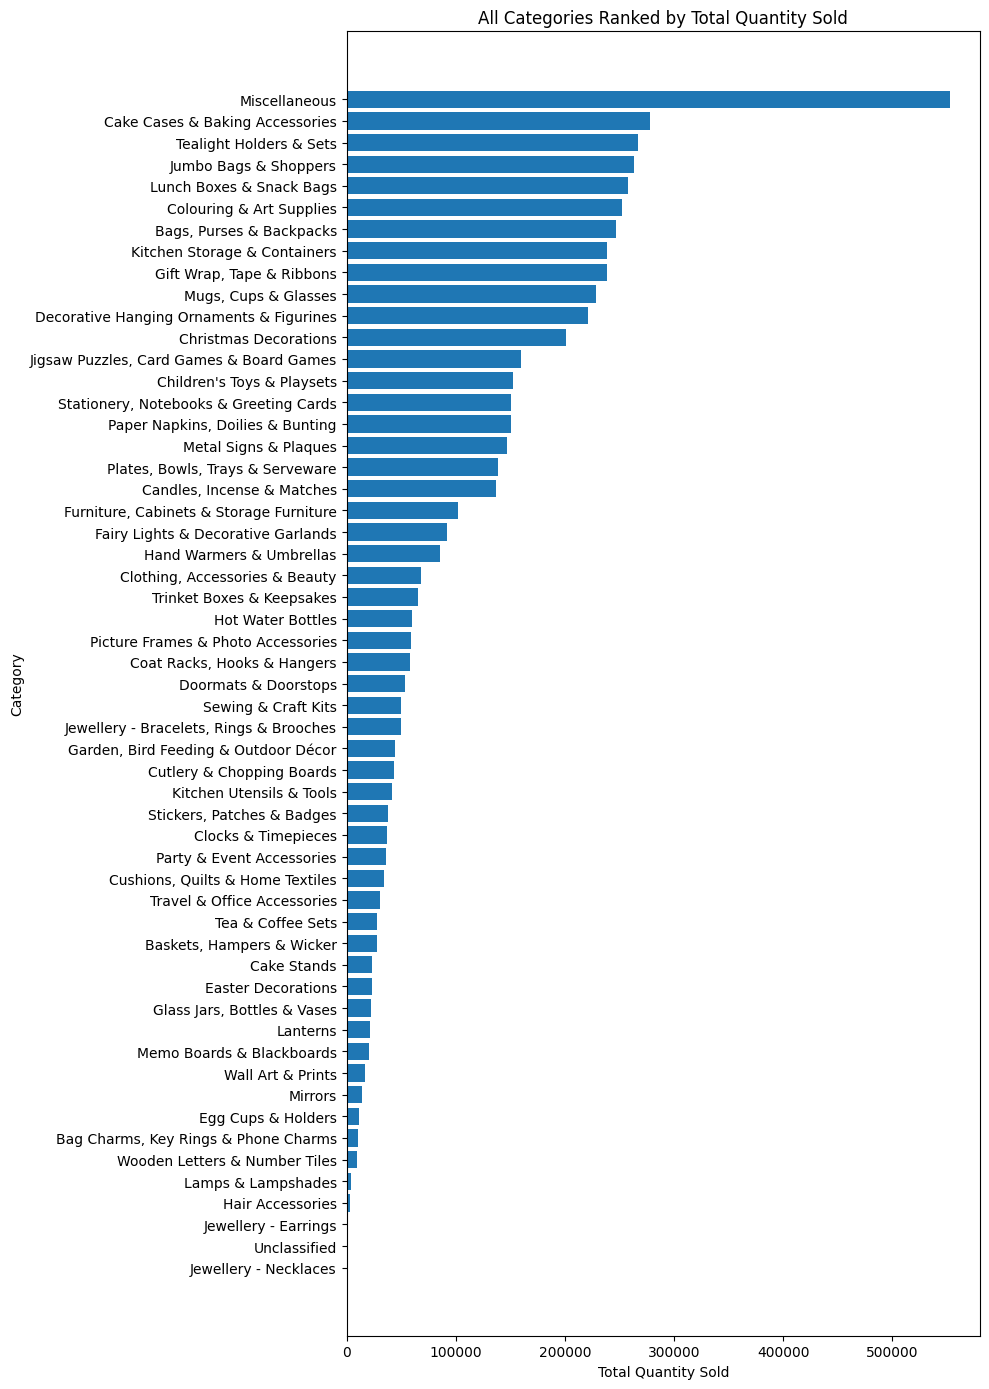

In [606]:
plt.figure(figsize=(10,14))

plt.barh(
    category_summary["Category"],
    category_summary["total_quantity"]
)

plt.gca().invert_yaxis()
plt.title("All Categories Ranked by Total Quantity Sold")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

### Interpretation

The first plot shows that **Miscellaneous** strongly dominates the dataset, with a much higher total quantity than the other categories.

However, this category is a catch-all group of heterogeneous products, so it may not represent a coherent demand pattern.

For this reason, I exclude **Miscellaneous** from the following category selection analysis and focus on more interpretable product categories.

In [608]:
daily = daily[daily["Category"]!="Miscellaneous"]
category_summary = category_summary[category_summary["Category"] != "Miscellaneous"]

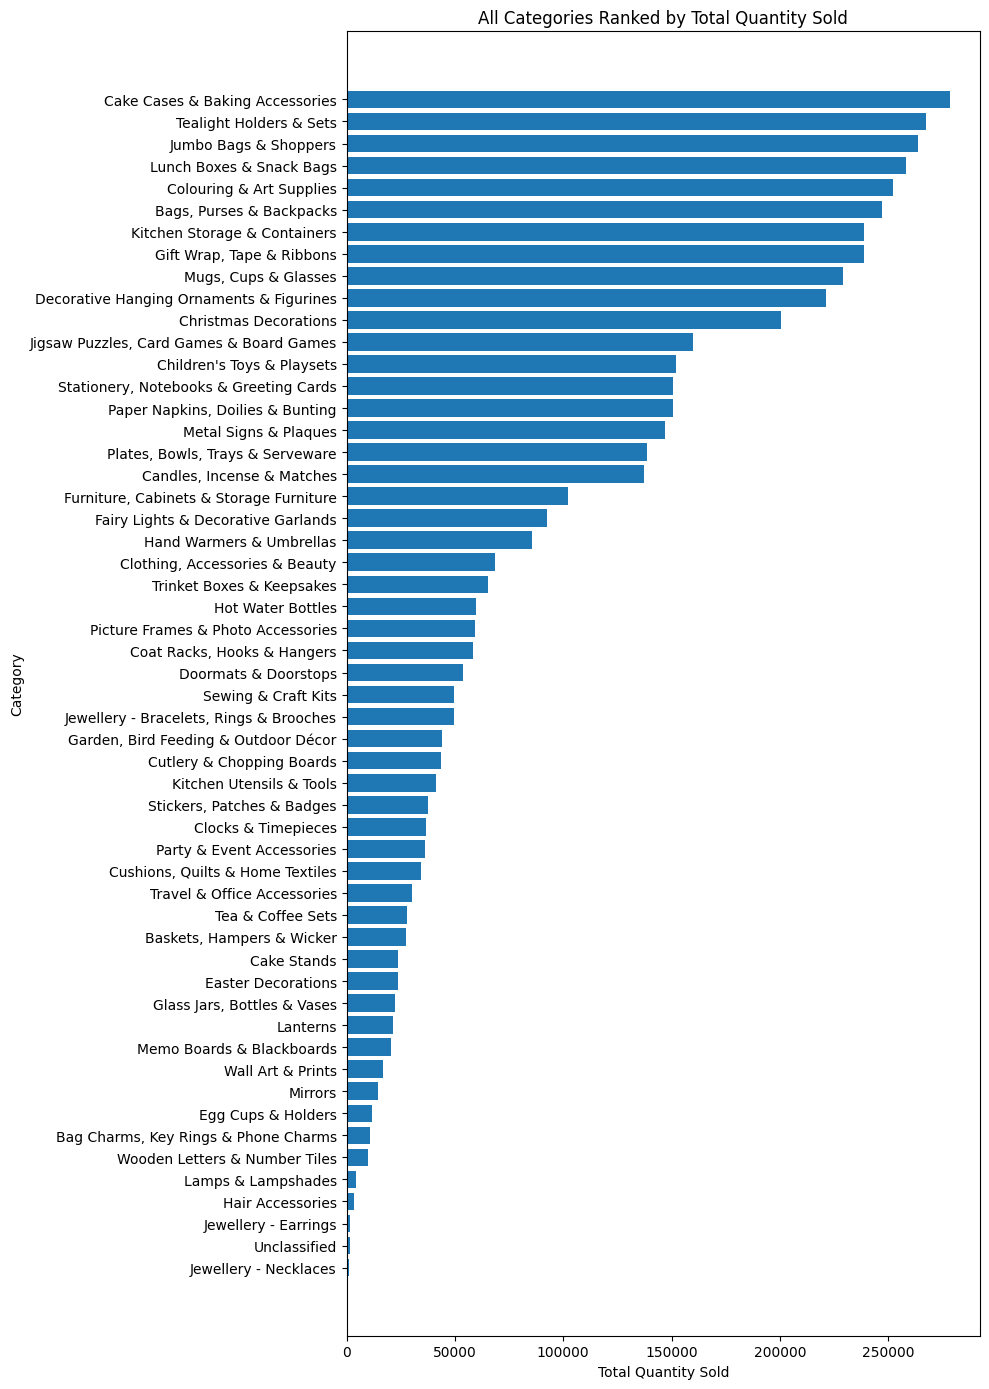

In [609]:
plt.figure(figsize=(10,14))

plt.barh(
    category_summary["Category"],
    category_summary["total_quantity"]
)

plt.gca().invert_yaxis()
plt.title("All Categories Ranked by Total Quantity Sold")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

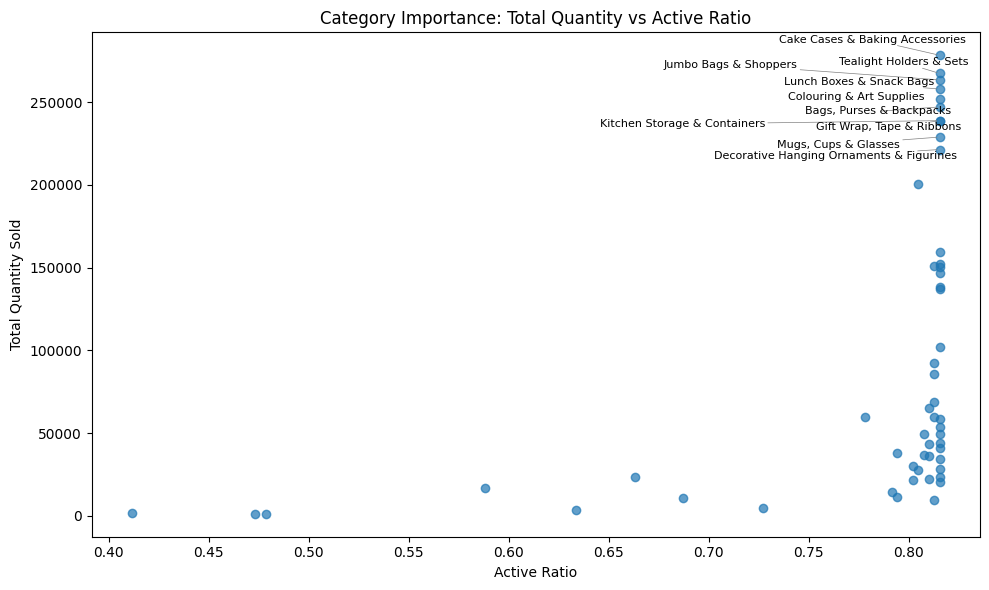

In [610]:

from adjustText import adjust_text

plt.figure(figsize=(10, 6))
plt.scatter(
    category_summary["active_ratio"],
    category_summary["total_quantity"],
    alpha=0.7
)

texts = []
for _, row in category_summary.head(10).iterrows():
    texts.append(plt.text(
        row["active_ratio"],
        row["total_quantity"],
        row["Category"],
        fontsize=8
    ))

adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

plt.title("Category Importance: Total Quantity vs Active Ratio")
plt.xlabel("Active Ratio")
plt.ylabel("Total Quantity Sold")
plt.tight_layout()
plt.show()

The scatter plot confirms that most high-volume categories cluster 
around an active ratio of 0.81 — meaning they sell on approximately 
81% of all days. These are the most suitable candidates for 
single-category forecasting models.

Categories in the bottom-left corner (active ratio < 0.65) are 
sparse and intermittent — standard regression models are less 
appropriate for these and they will be excluded from single-category 
modeling.

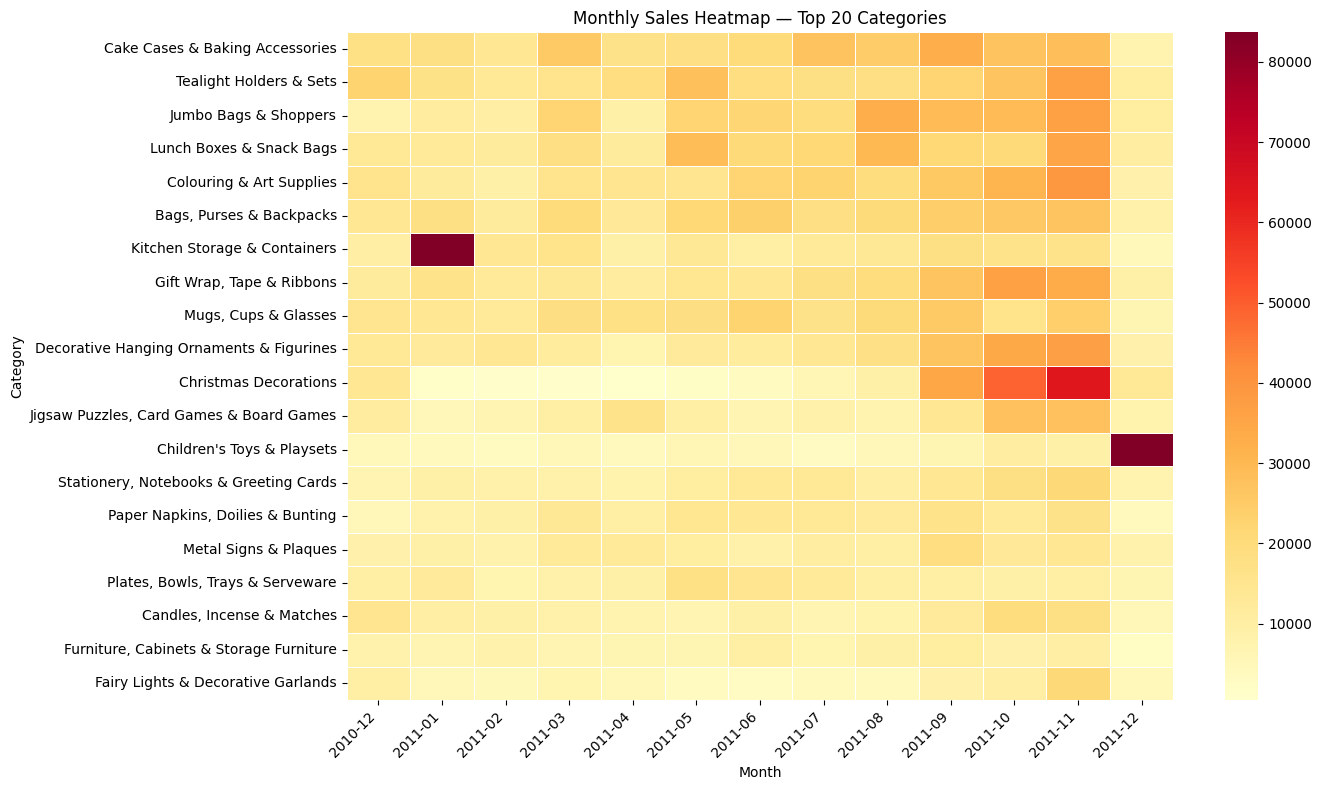

In [612]:
import seaborn as sns
top20 = category_summary.head(20)["Category"].tolist()

monthly_data = daily[daily["Category"].isin(top20)].copy()
monthly_data["Month"] = monthly_data["Date"].dt.to_period("M").dt.to_timestamp()

monthly_pivot = (
    monthly_data
    .pivot_table(
        index="Month",
        columns="Category",
        values="Quantity",
        aggfunc="sum"
    )
    .fillna(0)
)

# Sort by total quantity
monthly_pivot = monthly_pivot[
    monthly_pivot.sum().sort_values(ascending=False).index
]

plt.figure(figsize=(14, 8))
ax = sns.heatmap(
    monthly_pivot.T,
    cmap="YlOrRd",
    linewidths=0.5
)

ax.set_xticklabels(
    [t.get_text()[:7] for t in ax.get_xticklabels()],
    rotation=45,
    ha="right"
)

plt.title("Monthly Sales Heatmap — Top 20 Categories")
plt.tight_layout()
plt.show()

### Interpretation
The heatmap reveals distinct seasonal behaviors across categories:
- Most top categories show stable demand year-round with a slight 
  increase toward Q4.
- **Christmas Decorations** and **Children's Toys & Playsets** show stronger activity near the end of the year, especially around the Christmas period. This suggests seasonal behavior, although sales may still occur during other months.
- **Kitchen Storage & Containers** shows an isolated spike in January 2011, 
  likely a single large bulk order rather than a seasonal pattern.


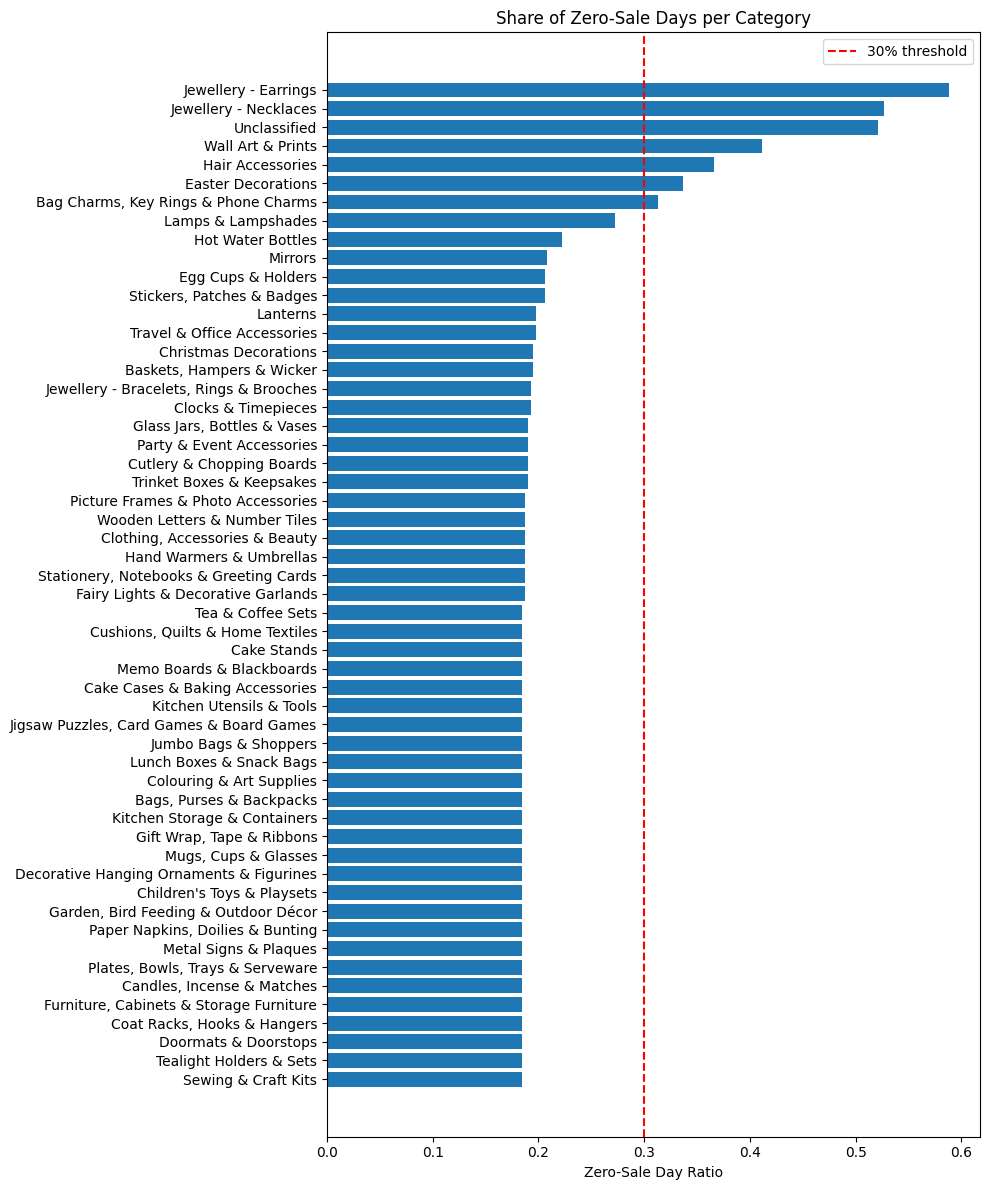

In [614]:
sparsity = category_summary.sort_values("zero_days", ascending=False)

plt.figure(figsize=(10, 12))
plt.barh(sparsity["Category"], sparsity["zero_days"] / sparsity["total_days"])
plt.gca().invert_yaxis()
plt.axvline(x=0.3, color="red", linestyle="--", label="30% threshold")
plt.title("Share of Zero-Sale Days per Category")
plt.xlabel("Zero-Sale Day Ratio")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation
Categories above the 30% threshold have too many zero-sale days 
to be reliably forecast with standard regression models. 
Jewellery categories are the most sparse (~55–60% zero-sales days).  
They are not suitable as standard forecasting candidates, but one Jewellery category is kept as an intermittent-demand stress-test case.

Categories below the threshold show regular daily sales and are 
the most suitable candidates for forecasting.

### Step 4: Category Selection

Based on total volume, active ratio, sparsity, and seasonal behavior, I select five representative categories that cover different forecasting situations:

1. **Tealight Holders & Sets** — high volume and regular demand. Good candidate for standard forecasting models.

2. **Cake Cases & Baking Accessories** — high volume and relatively stable demand. Useful as a strong baseline category.

3. **Jumbo Bags & Shoppers** — high volume but more volatile. This category tests model robustness on noisy demand.

4. **Christmas Decorations** — seasonal category with stronger activity around the end-of-year period. This tests whether models can capture seasonal behavior.

5. **Jewellery - Earrings** — sparse/intermittent category with many zero-sales days. It is included as a stress-test case, not as a standard forecasting candidate.

In [619]:
selected_categories = [
    "Tealight Holders & Sets",
    "Cake Cases & Baking Accessories",
    "Jumbo Bags & Shoppers",
    "Christmas Decorations",
    "Jewellery - Earrings"
]

selected_data = daily[daily["Category"].isin(selected_categories)].copy()
print(f"Selected {len(selected_categories)} categories")
print(f"Rows: {len(selected_data)}")

Selected 5 categories
Rows: 1870


### Step 5: Time Series Visualization of Selected Categories

We plot the daily sales for each selected category to visually inspect 
their behavior before modeling.

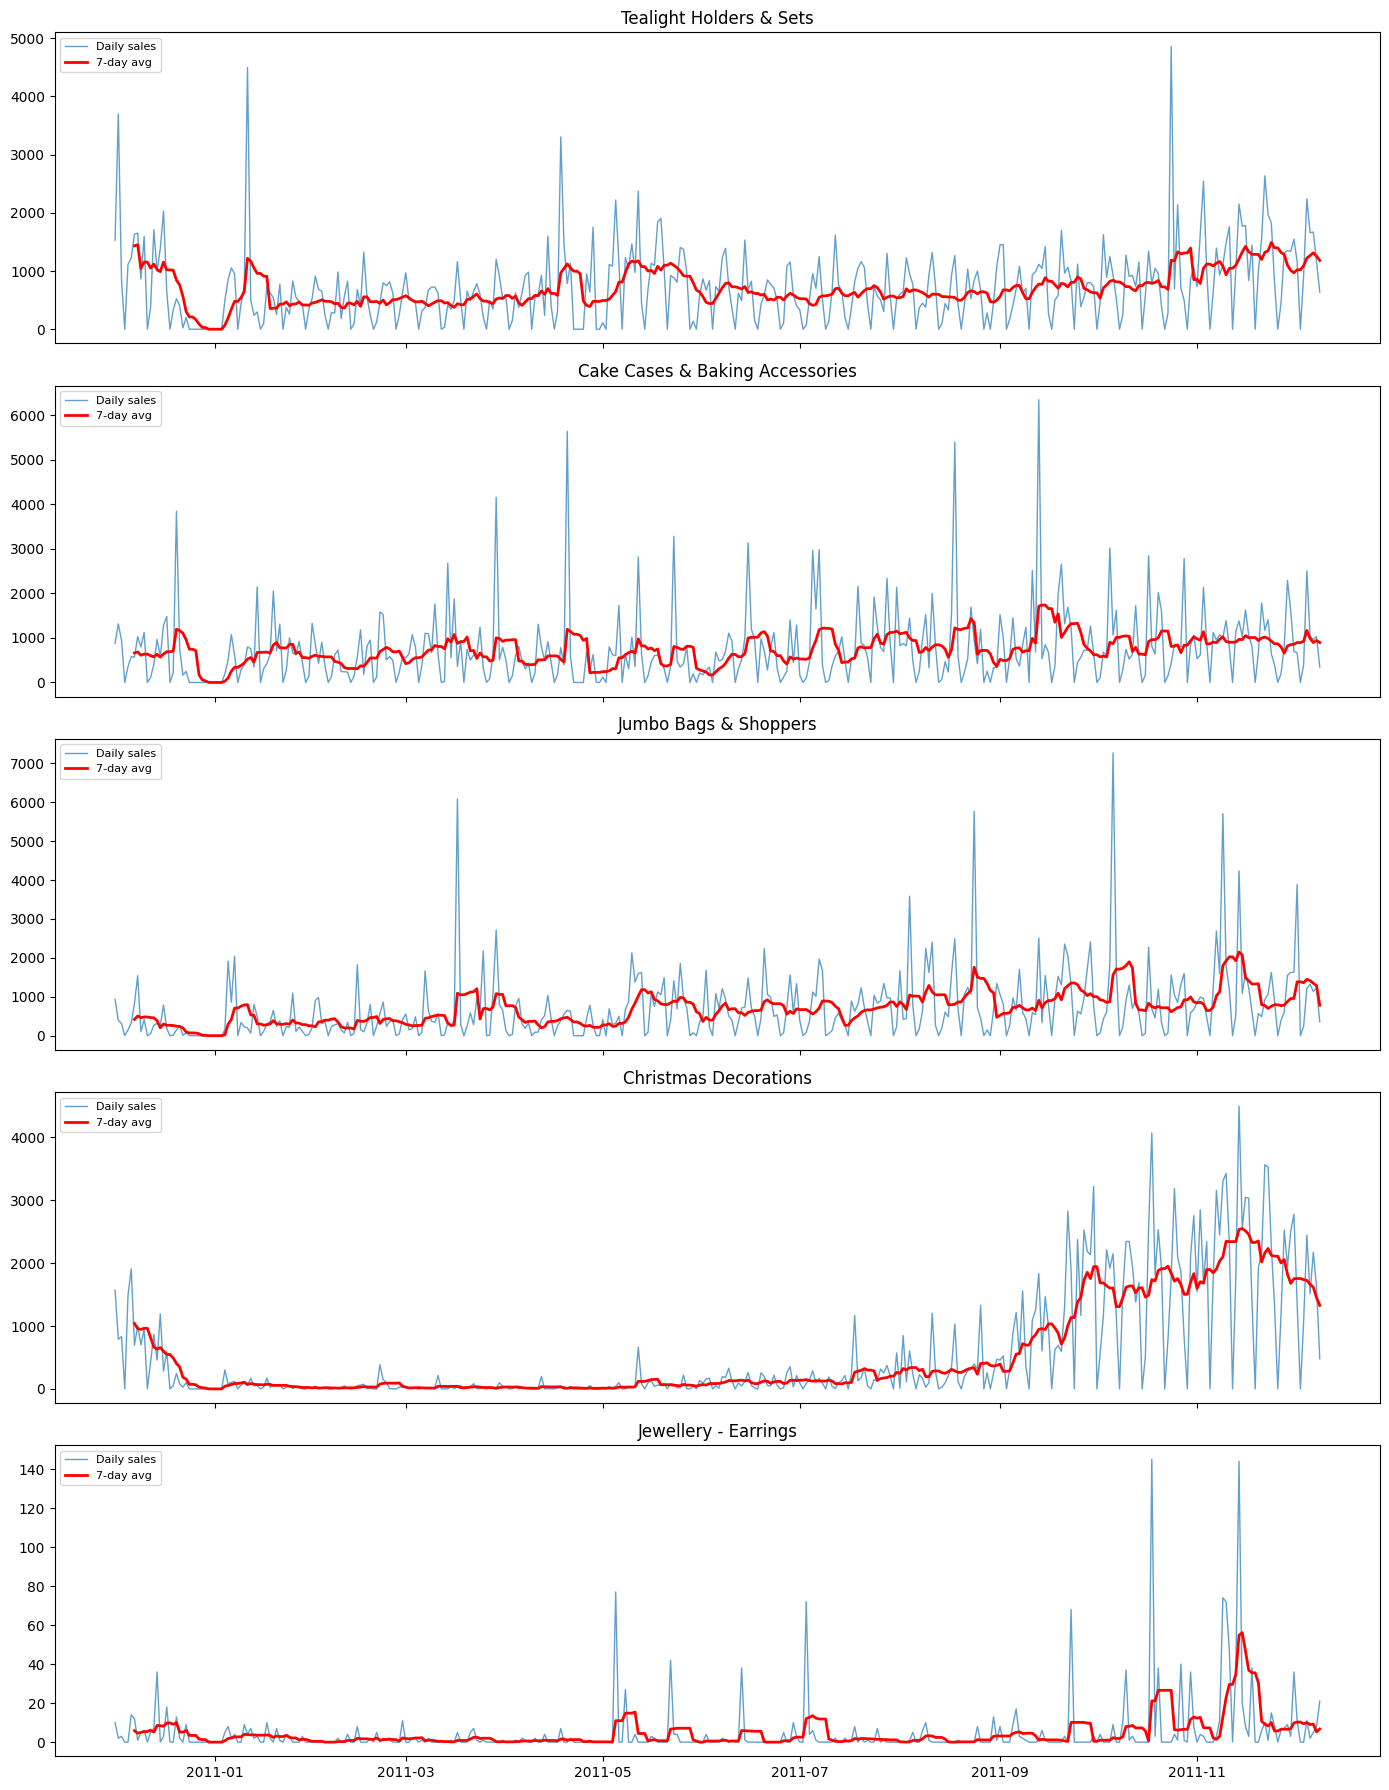

In [623]:
fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)

for ax, cat in zip(axes, selected_categories):
    s = selected_data[selected_data["Category"] == cat].set_index("Date")["Quantity"].sort_index()
    ax.plot(s.index, s.values, lw=1, alpha=0.7, label="Daily sales")
    ax.plot(s.index, s.rolling(7).mean(), lw=2, color="red", label="7-day avg")
    ax.set_title(cat)
    ax.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

### Interpretation of Selected Category Time Series

The selected categories show different demand behaviors.

**Tealight Holders & Sets** and **Cake Cases & Baking Accessories** have frequent sales with visible fluctuations. These categories are suitable for standard forecasting models such as SARIMA, Random Forest, and XGBoost.

**Jumbo Bags & Shoppers** has high sales volume but appears more volatile, with several sales spikes. This category can be used to test whether the models handle noisy demand patterns.

**Christmas Decorations** shows stronger seasonal behavior, especially near the end of the year. This category may require seasonal features or seasonal time series models.

**Jewellery - Earrings** is much sparser, with many zero-sales days. This category may be difficult for standard regression models and may require a different forecasting approach.

Overall, these five categories provide a useful set of forecasting cases: regular demand, volatile demand, seasonal demand, and intermittent demand.

### Step 6: Explore Time Series Outcomes and Correlations

In this step, I analyze whether the selected category outcomes move together over time.

The objective is to understand whether some categories have similar demand patterns, common seasonal behavior, or correlated sales movements.

This can help decide whether categories should be modeled separately, grouped together, or enriched with cross-category features.

In [627]:
## Create pivot table 
selected_daily = daily[daily["Category"].isin(selected_categories)].copy()

category_pivot = (
    selected_daily
    .pivot_table(
        index="Date",
        columns="Category",
        values="Quantity",
        aggfunc="sum"
    )
    .fillna(0)
)

category_pivot.head()

Category,Cake Cases & Baking Accessories,Christmas Decorations,Jewellery - Earrings,Jumbo Bags & Shoppers,Tealight Holders & Sets
Date,,,,,
2010-12-01,879,1571,10,932,1530
2010-12-02,1314,790,2,393,3697
2010-12-03,946,831,3,309,841
2010-12-04,0,0,0,0,0
2010-12-05,359,1486,0,150,1112


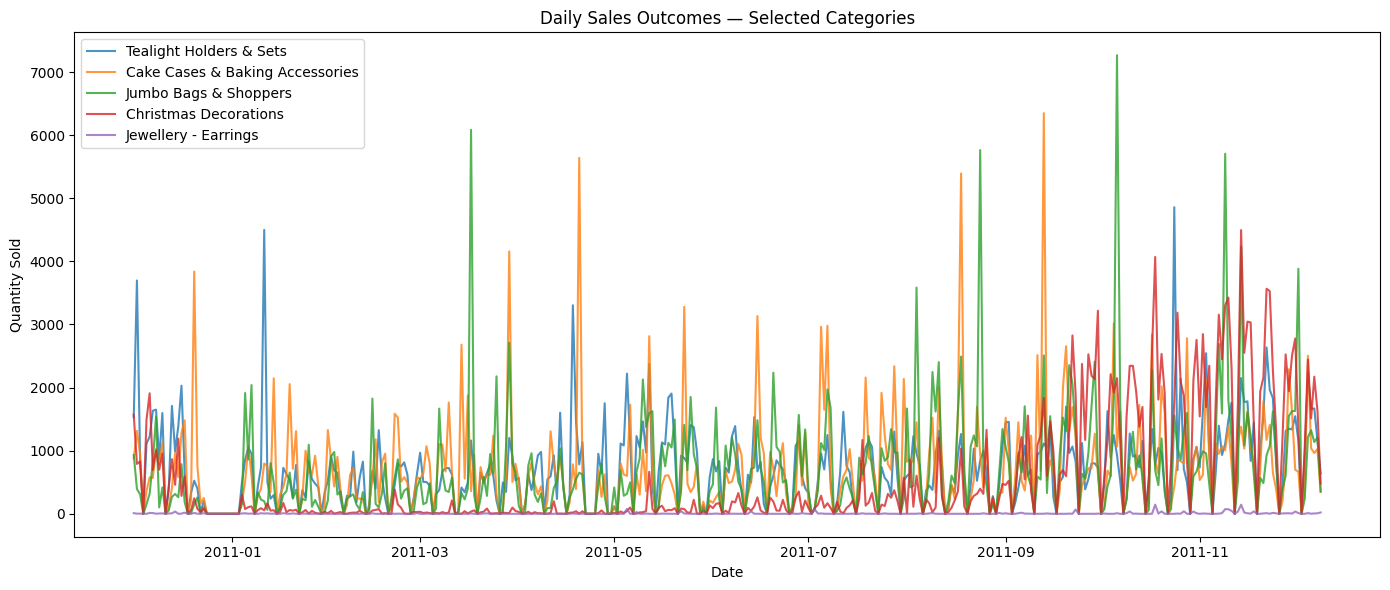

In [629]:
## Plot selected category outcomes together
plt.figure(figsize=(14, 6))

for category in selected_categories:
    plt.plot(
        category_pivot.index,
        category_pivot[category],
        label=category,
        alpha=0.8
    )

plt.title("Daily Sales Outcomes — Selected Categories")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.legend()
plt.tight_layout()
plt.show()

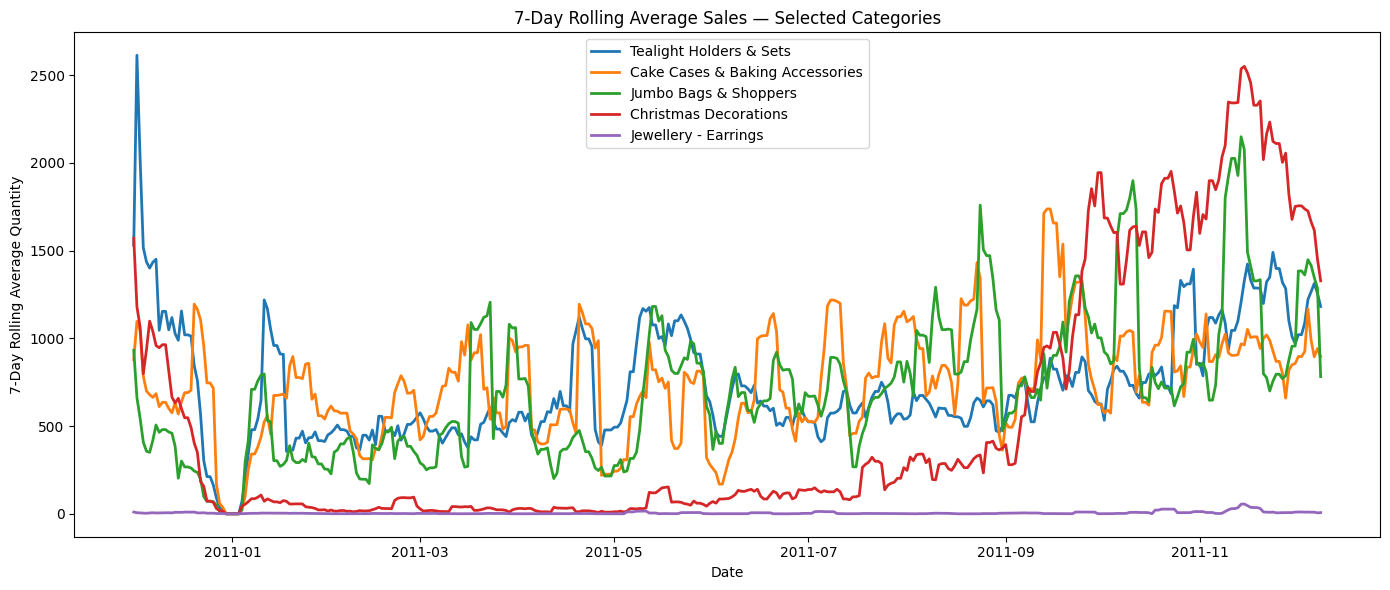

In [631]:
## Plot 7-day rolling average together
rolling_category_pivot = category_pivot.rolling(7, min_periods=1).mean()

plt.figure(figsize=(14, 6))

for category in selected_categories:
    plt.plot(
        rolling_category_pivot.index,
        rolling_category_pivot[category],
        label=category,
        linewidth=2
    )

plt.title("7-Day Rolling Average Sales — Selected Categories")
plt.xlabel("Date")
plt.ylabel("7-Day Rolling Average Quantity")
plt.legend()
plt.tight_layout()
plt.show()

In [632]:
## Correlation Matrix
category_corr = category_pivot.corr()

category_corr

Category,Cake Cases & Baking Accessories,Christmas Decorations,Jewellery - Earrings,Jumbo Bags & Shoppers,Tealight Holders & Sets
Category,,,,,
Cake Cases & Baking Accessories,1.000000,0.288139,0.065189,0.398814,0.372578
Christmas Decorations,0.288139,1.000000,0.454617,0.409419,0.451641
Jewellery - Earrings,0.065189,0.454617,1.000000,0.234004,0.206722
Jumbo Bags & Shoppers,0.398814,0.409419,0.234004,1.000000,0.382019
Tealight Holders & Sets,0.372578,0.451641,0.206722,0.382019,1.000000


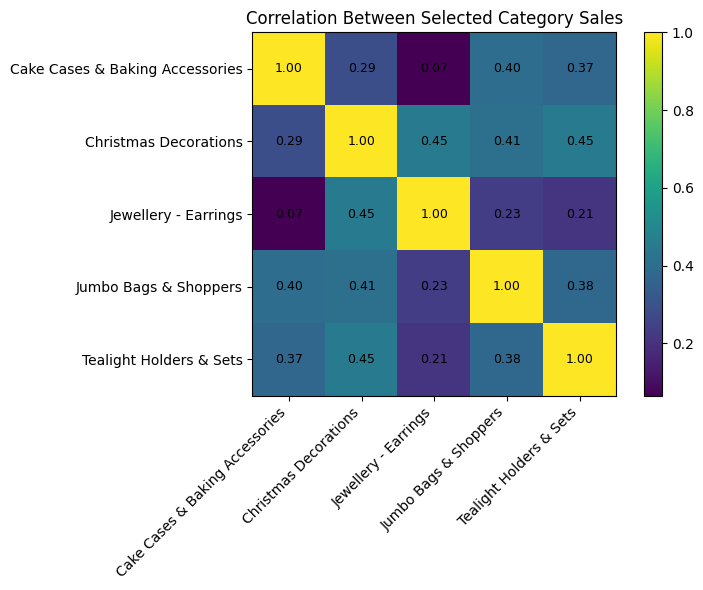

In [633]:
## Correlation Heatmap
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(category_corr.values)

ax.set_xticks(range(len(category_corr.columns)))
ax.set_yticks(range(len(category_corr.index)))

ax.set_xticklabels(category_corr.columns, rotation=45, ha="right")
ax.set_yticklabels(category_corr.index)

for i in range(len(category_corr.index)):
    for j in range(len(category_corr.columns)):
        ax.text(
            j,
            i,
            f"{category_corr.values[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=9
        )

plt.colorbar(im, ax=ax)
ax.set_title("Correlation Between Selected Category Sales")
plt.tight_layout()
plt.show()

### Interpretation

The selected categories show different sales behaviors over time.

The daily time series plot shows that some categories have regular demand, while others are more volatile or sparse. The 7-day rolling average helps smooth short-term fluctuations and makes the global sales patterns easier to compare.

The correlation matrix shows that the selected categories are not strongly correlated overall. Most correlations are low to moderate, which means that the categories do not always increase or decrease together.

This supports the decision to build separate forecasting models for each category instead of using only one global model.

Some moderate correlations may indicate shared demand periods, common seasonality, or similar customer behavior. However, the correlations are not strong enough to assume that all categories follow the same sales pattern.

### Step 7: Prepare Single-Category Forecasting Datasets
For each selected category, I create a separate forecasting dataset.

The objective is to drop all other categories and keep only one category at a time.  
This allows each model to learn the specific behavior of one category instead of learning a global pattern across all categories.

For each category, I create:

- the forecasting target `target_X7_Y7`;
- lag features such as `lag_1`, `lag_7`, `lag_14`, and `lag_28`;
- rolling-window features such as `rolling_mean_7` and `rolling_sum_7`;
- calendar features such as day of week and month.

In [637]:
X = 7  # prediction horizon: next 7 days
Y = 7  # prediction made 7 days in advance

target_col = f"target_X{X}_Y{Y}"

target_col

'target_X7_Y7'

#### Integration of Holiday Features

To better capture seasonal demand fluctuations, three holiday-related variables were added during the feature engineering stage:

- **is_holiday**: Indicates whether the current observation corresponds to a public holiday.
- **number_of_holidays_in_target_window**: Counts the number of public holidays occurring during the forecasting horizon.
- **holiday_in_target_window**: Binary indicator showing whether at least one holiday falls within the forecasting horizon.

These variables were included alongside the lag, rolling, trend, and calendar features. Their usefulness was assessed indirectly during the subsequent model selection, feature selection, and hyperparameter tuning stages. Features that did not contribute to predictive performance were naturally discarded by the feature selection process or not retained in the final models.

In [640]:
import pandas as pd

# England and Wales holidays relevant to the dataset period
# Actual holidays and substitute bank-holiday dates are included
holiday_dates = set(
    pd.to_datetime([
        # 2010
        "2010-12-25",  # Christmas Day
        "2010-12-26",  # Boxing Day
        "2010-12-27",  # Christmas substitute day
        "2010-12-28",  # Boxing Day substitute day

        # 2011
        "2011-01-01",  # New Year's Day
        "2011-01-03",  # New Year's substitute day
        "2011-04-22",  # Good Friday
        "2011-04-25",  # Easter Monday
        "2011-04-29",  # Royal Wedding public holiday
        "2011-05-02",  # Early May bank holiday
        "2011-05-30",  # Spring bank holiday
        "2011-08-29",  # Summer bank holiday
        "2011-12-25",  # Christmas Day
        "2011-12-26",  # Boxing Day
        "2011-12-27"   # Christmas substitute day
    ]).date
)

print("Number of holiday dates:", len(holiday_dates))
print(sorted(holiday_dates))

Number of holiday dates: 15
[datetime.date(2010, 12, 25), datetime.date(2010, 12, 26), datetime.date(2010, 12, 27), datetime.date(2010, 12, 28), datetime.date(2011, 1, 1), datetime.date(2011, 1, 3), datetime.date(2011, 4, 22), datetime.date(2011, 4, 25), datetime.date(2011, 4, 29), datetime.date(2011, 5, 2), datetime.date(2011, 5, 30), datetime.date(2011, 8, 29), datetime.date(2011, 12, 25), datetime.date(2011, 12, 26), datetime.date(2011, 12, 27)]


In [641]:
def prepare_single_category_dataset(daily_data,category_name,X=7,Y=7,category_pivot=None,correlated_categories=None,holiday_dates=None):
    """
    Prepare a forecasting dataset for one category.
    The target is the total quantity sold during the next X days,
    starting Y days after the current date.
    """
    # Keep only the selected category
    category_data = (daily_data[daily_data["Category"] == category_name]
        .sort_values("Date").copy())
    # Keep useful columns
    category_data=category_data[["Date", "Category", "Quantity", "Revenue", "Orders"]].copy()

    # Prepare dates
    category_data["Date"] = pd.to_datetime(category_data["Date"])
    category_data = (category_data.sort_values("Date").reset_index(drop=True))
    # -------------------------------------------------
    # Create forecasting target
    # -------------------------------------------------
    quantities = category_data["Quantity"].to_numpy()
    targets = []
    for i in range(len(category_data)):
        start = i + Y
        end = start + X
        if end <= len(category_data):
            targets.append(quantities[start:end].sum())
        else:
            targets.append(np.nan)
    target_col = f"target_X{X}_Y{Y}"
    category_data[target_col] = targets
    # -------------------------------------------------
    # Daily lag features: previous seven observations
    # -------------------------------------------------
    for lag in range(1, 8):
        category_data[f"lag_{lag}"] = (category_data["Quantity"].shift(lag))

    # Longer-term lags
    category_data["lag_14"] = (category_data["Quantity"].shift(14))
    category_data["lag_28"] = (category_data["Quantity"].shift(28))
    # -------------------------------------------------
    # Rolling features based only on past observations
    # -------------------------------------------------
    shifted_quantity = category_data["Quantity"].shift(1)
    for window in [7, 14, 28]:
        
        category_data[f"rolling_mean_{window}"] = (
            shifted_quantity.rolling(window).mean())
        
        category_data[f"rolling_std_{window}"] = (
            shifted_quantity.rolling(window).std())
        
        category_data[f"rolling_min_{window}"] = (
            shifted_quantity.rolling(window).min())
        
        category_data[f"rolling_max_{window}"] = (
            shifted_quantity.rolling(window).max())

        category_data[f"rolling_sum_{window}"] = (
            shifted_quantity.rolling(window).sum())
    # -------------------------------------------------
    # Weekly averages over the previous month
    # -------------------------------------------------
    # rolling_mean_7 represents the most recent week
    category_data["weekly_mean_2"] = (
        shifted_quantity.shift(7).rolling(7).mean())

    category_data["weekly_mean_3"] = (
        shifted_quantity.shift(14).rolling(7).mean())

    category_data["weekly_mean_4"] = (
        shifted_quantity.shift(21).rolling(7).mean())
    # -------------------------------------------------
    # Trend feature
    # -------------------------------------------------
    category_data["trend_7_28"] = (
        category_data["rolling_mean_7"]- category_data["rolling_mean_28"])
    # -------------------------------------------------
    # Calendar features
    # -------------------------------------------------
    category_data["day_of_week"] = (category_data["Date"].dt.dayofweek)
    category_data["month"] = (category_data["Date"].dt.month)
    # -------------------------------------------------
    # Holiday-related features
    # -------------------------------------------------
    if holiday_dates is not None:
        # Convert holiday dates to Python date objects
        holiday_dates_set = {pd.Timestamp(date).date() for date in holiday_dates
        }
        # Indicates whether the current date is a holiday
        category_data["is_holiday"] = (
            category_data["Date"].dt.date.isin(holiday_dates_set).astype(int)
        )
        holiday_flags = (
            category_data["is_holiday"].to_numpy()
        )
        holiday_counts = []

        # Count holidays in the exact target window: rows i + Y to i + Y + X - 1
        for i in range(len(category_data)):
            start = i + Y
            end = start + X
            if end <= len(category_data):
                holiday_counts.append(holiday_flags[start:end].sum())
            else:
                holiday_counts.append(np.nan)

        category_data["number_of_holidays_in_target_window"] = holiday_counts

        # Indicates whether at least one holiday occurs inside the target forecasting window
        category_data["holiday_in_target_window"] = np.where(
            category_data["number_of_holidays_in_target_window"].isna(),np.nan,(category_data["number_of_holidays_in_target_window"] > 0).astype(int)
        )

    # -------------------------------------------------
    # Lagged demand from correlated categories
    # -------------------------------------------------
    if (category_pivot is not None and correlated_categories is not None):
        for i, correlated_category in enumerate(correlated_categories,start=1):
            correlated_data = (category_pivot[correlated_category]
                .shift(1).rename(f"correlated_category_{i}_lag_1").reset_index())
            category_data = category_data.merge(correlated_data,on="Date",how="left")
    # -------------------------------------------------
    # Remove rows with unavailable target or features
    # -------------------------------------------------
    category_data = (category_data.dropna().reset_index(drop=True))

    return category_data

In [642]:
tmp = prepare_single_category_dataset(
    daily_data=daily,
    category_name=selected_categories[0],
    X=X,
    Y=Y,
    holiday_dates=holiday_dates
)

print(tmp.columns.tolist())

['Date', 'Category', 'Quantity', 'Revenue', 'Orders', 'target_X7_Y7', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_std_7', 'rolling_min_7', 'rolling_max_7', 'rolling_sum_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_min_14', 'rolling_max_14', 'rolling_sum_14', 'rolling_mean_28', 'rolling_std_28', 'rolling_min_28', 'rolling_max_28', 'rolling_sum_28', 'weekly_mean_2', 'weekly_mean_3', 'weekly_mean_4', 'trend_7_28', 'day_of_week', 'month', 'is_holiday', 'number_of_holidays_in_target_window', 'holiday_in_target_window']


In [645]:
single_category_datasets = {}

for category in selected_categories:
    single_category_datasets[category] = prepare_single_category_dataset(
        daily_data=daily,
        category_name=category,
        X=X,
        Y=Y,
        holiday_dates=holiday_dates
    )

single_category_datasets.keys()

dict_keys(['Tealight Holders & Sets', 'Cake Cases & Baking Accessories', 'Jumbo Bags & Shoppers', 'Christmas Decorations', 'Jewellery - Earrings'])

In [651]:
example_category = selected_categories[0]

single_category_datasets[example_category].head()

,Date,Category,Quantity,Revenue,Orders,target_X7_Y7,lag_1,lag_2,lag_3,lag_4,...,rolling_sum_28,weekly_mean_2,weekly_mean_3,weekly_mean_4,trend_7_28,day_of_week,month,is_holiday,number_of_holidays_in_target_window,holiday_in_target_window
0,2010-12-29,Tealight Holders & Sets,0,0.0,0,8534.0,0.0,0.0,0.0,0.0,...,22766.0,759.857143,1026.714286,1433.571429,-780.928571,2,12,0,0.0,0.0
1,2010-12-30,Tealight Holders & Sets,0,0.0,0,8182.0,0.0,0.0,0.0,0.0,...,21236.0,565.142857,989.000000,1450.857143,-729.714286,3,12,0,0.0,0.0
2,2010-12-31,Tealight Holders & Sets,0,0.0,0,7370.0,0.0,0.0,0.0,0.0,...,17539.0,303.857143,1155.714286,1046.000000,-626.392857,4,12,0,0.0,0.0
3,2011-01-01,Tealight Holders & Sets,0,0.0,0,6714.0,0.0,0.0,0.0,0.0,...,16698.0,211.714286,1019.857143,1153.857143,-596.357143,5,1,1,0.0,0.0
4,2011-01-02,Tealight Holders & Sets,0,0.0,0,6714.0,0.0,0.0,0.0,0.0,...,16698.0,211.714286,1019.857143,1153.857143,-596.357143,6,1,0,0.0,0.0


In [655]:
for category, data in single_category_datasets.items():
    print(category, ":", data.shape)

Tealight Holders & Sets : (333, 39)
Cake Cases & Baking Accessories : (333, 39)
Jumbo Bags & Shoppers : (333, 39)
Christmas Decorations : (333, 39)
Jewellery - Earrings : (333, 39)


### Step 8: Train / Validation / Test Split

For each single-category dataset, I use a chronological train / validation / test split.

- The training set is used to fit the models.  
- The validation set is used to compare models and tune modeling choices.  
- The test set is kept for final evaluation.

A chronological split is necessary because this is a forecasting problem. The model should learn from past observations and be evaluated on future observations.

In [658]:
def time_train_val_test_split(data, train_size=0.6, val_size=0.2):
    data = data.sort_values("Date").reset_index(drop=True)
    
    n = len(data)
    
    train_end = int(n * train_size)
    val_end = int(n * (train_size + val_size))
    
    train_df = data.iloc[:train_end].copy()
    val_df = data.iloc[train_end:val_end].copy()
    test_df = data.iloc[val_end:].copy()
    
    return train_df, val_df, test_df

In [660]:
single_category_splits = {}

for category, data in single_category_datasets.items():
    train_df, val_df, test_df = time_train_val_test_split(data)
    
    single_category_splits[category] = {
        "train": train_df,
        "validation": val_df,
        "test": test_df
    }
    
    print(category)
    print("Train:", train_df["Date"].min(), "to", train_df["Date"].max(), train_df.shape)
    print("Validation:", val_df["Date"].min(), "to", val_df["Date"].max(), val_df.shape)
    print("Test:", test_df["Date"].min(), "to", test_df["Date"].max(), test_df.shape)
    print("-" * 80)

Tealight Holders & Sets
Train: 2010-12-29 00:00:00 to 2011-07-15 00:00:00 (199, 39)
Validation: 2011-07-16 00:00:00 to 2011-09-20 00:00:00 (67, 39)
Test: 2011-09-21 00:00:00 to 2011-11-26 00:00:00 (67, 39)
--------------------------------------------------------------------------------
Cake Cases & Baking Accessories
Train: 2010-12-29 00:00:00 to 2011-07-15 00:00:00 (199, 39)
Validation: 2011-07-16 00:00:00 to 2011-09-20 00:00:00 (67, 39)
Test: 2011-09-21 00:00:00 to 2011-11-26 00:00:00 (67, 39)
--------------------------------------------------------------------------------
Jumbo Bags & Shoppers
Train: 2010-12-29 00:00:00 to 2011-07-15 00:00:00 (199, 39)
Validation: 2011-07-16 00:00:00 to 2011-09-20 00:00:00 (67, 39)
Test: 2011-09-21 00:00:00 to 2011-11-26 00:00:00 (67, 39)
--------------------------------------------------------------------------------
Christmas Decorations
Train: 2010-12-29 00:00:00 to 2011-07-15 00:00:00 (199, 39)
Validation: 2011-07-16 00:00:00 to 2011-09-20 00:00

In [664]:
train_df = single_category_splits[selected_categories[0]]["train"]

features = [
    col for col in train_df.columns
    if col not in ["Date", "Category", target_col]
]

print(features)
print(len(features))

['Quantity', 'Revenue', 'Orders', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_std_7', 'rolling_min_7', 'rolling_max_7', 'rolling_sum_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_min_14', 'rolling_max_14', 'rolling_sum_14', 'rolling_mean_28', 'rolling_std_28', 'rolling_min_28', 'rolling_max_28', 'rolling_sum_28', 'weekly_mean_2', 'weekly_mean_3', 'weekly_mean_4', 'trend_7_28', 'day_of_week', 'month', 'is_holiday', 'number_of_holidays_in_target_window', 'holiday_in_target_window']
36


In [678]:
train_df = single_category_splits[selected_categories[0]]["train"]

missing_features = [
    feature for feature in features
    if feature not in train_df.columns
]

print("Missing features:", missing_features)

Missing features: []


### Step 9: Train Separate Models for Each Category

In this step, I train separate forecasting models for each selected category.

For each category, the models are trained only on that category's data.  
This allows each model to learn the specific demand behavior of one category.

The first models tested are:

- Moving Average baseline;
- Linear Regression;
- Random Forest Regressor.
- XGBoost Regressor.

The models are compared first on the validation set, then evaluated on the test set.

In [681]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
from xgboost import XGBRegressor

In [682]:
def evaluate_forecast(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    y_pred = np.maximum(y_pred, 0)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    denominator = np.sum(np.abs(y_true))

    if denominator == 0:
        wape = np.nan
    else:
        wape = (np.sum(np.abs(y_true - y_pred))/ denominator) * 100

    r2 = r2_score(y_true, y_pred)
    bias = np.mean(y_pred - y_true)

    return mae, rmse, wape, r2, bias

In [683]:
features = [
    "lag_1","lag_2","lag_3","lag_4","lag_5","lag_6","lag_7","lag_14","lag_28",
    
    "rolling_std_7", "rolling_std_14","rolling_std_28",
    
    "rolling_min_7","rolling_min_14","rolling_min_28",
    
    "rolling_max_7","rolling_max_14","rolling_max_28",
    
    "rolling_mean_7","rolling_mean_14","rolling_mean_28",
    
    "weekly_mean_2","weekly_mean_3","weekly_mean_4",
    
    "trend_7_28",
    "day_of_week",
    "month",
    # Holiday features
    'is_holiday','number_of_holidays_in_target_window','holiday_in_target_window'
]

target_col = "target_X7_Y7"

In [684]:
all_results = []

for category, splits in single_category_splits.items():
    train_df = splits["train"]
    val_df = splits["validation"]
    test_df = splits["test"]
    
    X_train = train_df[features]
    y_train = train_df[target_col]
    
    X_val = val_df[features]
    y_val = val_df[target_col]
    
    X_test = test_df[features]
    y_test = test_df[target_col]
    
    models = {
        "Moving Average 7 days": None,
        "Linear Regression": LinearRegression(),
        "Random Forest": RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),
        "XGBoost": XGBRegressor(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=6,
            random_state=42,
            n_jobs=-1
        )
    }
    
    for model_name, model in models.items():
        
        if model_name == "Moving Average 7 days":
            val_pred = val_df["rolling_sum_7"].values
            test_pred = test_df["rolling_sum_7"].values
        
        else:
            model.fit(X_train, y_train)
            val_pred = model.predict(X_val)
            test_pred = model.predict(X_test)
        
        val_mae, val_rmse, val_wape, val_r2, val_bias = evaluate_forecast(y_val, val_pred)
        test_mae, test_rmse, test_wape, test_r2, test_bias = evaluate_forecast(y_test, test_pred)
        
        all_results.append({
            "Category": category,
            "Model": model_name,
            "Validation MAE": val_mae,
            "Validation RMSE": val_rmse,
            "Validation WAPE (%)": val_wape,
            "Validation R2": val_r2,
            "Validation Bias": val_bias,
            "Test MAE": test_mae,
            "Test RMSE": test_rmse,
            "Test WAPE (%)": test_wape,
            "Test R2": test_r2,
            "Test Bias": test_bias
        })

results_single_category = pd.DataFrame(all_results)

results_single_category = results_single_category.sort_values(
    ["Category", "Validation WAPE (%)"]).reset_index(drop=True)

results_single_category.round(3)

,Category,Model,Validation MAE,Validation RMSE,Validation WAPE (%),Validation R2,Validation Bias,Test MAE,Test RMSE,Test WAPE (%),Test R2,Test Bias
0,Cake Cases & Baking Accessories,Linear Regression,2137.460,2881.750,32.065,-0.432,-1802.751,1235.144,1479.141,19.264,-1.695,-950.544
1,Cake Cases & Baking Accessories,Random Forest,2224.527,3135.845,33.371,-0.696,-1989.601,1507.637,1736.417,23.514,-2.714,-1372.881
2,Cake Cases & Baking Accessories,XGBoost,2576.798,3502.808,38.656,-1.116,-2492.203,1961.215,2258.985,30.588,-5.286,-1802.662
3,Cake Cases & Baking Accessories,Moving Average 7 days,3521.866,4248.072,52.833,-2.112,-251.806,991.134,1238.302,15.458,-0.889,78.507
4,Christmas Decorations,Moving Average 7 days,1868.985,2716.925,40.928,0.399,-1800.716,2681.134,3277.551,20.641,-1.172,-441.015
5,Christmas Decorations,Linear Regression,2391.198,3347.501,52.364,0.088,-2364.349,5688.828,6401.341,43.797,-7.284,-5679.807
6,Christmas Decorations,XGBoost,2901.366,4518.582,63.536,-0.661,-2839.515,11204.618,11430.207,86.261,-25.413,-11204.618
7,Christmas Decorations,Random Forest,2908.741,4537.760,63.698,-0.675,-2887.322,11372.784,11590.545,87.556,-26.159,-11372.784
8,Jewellery - Earrings,Random Forest,12.431,20.551,69.346,-0.016,-7.550,75.773,116.971,77.853,-0.694,-73.053
9,Jewellery - Earrings,XGBoost,12.874,21.513,71.820,-0.113,-8.033,78.562,118.101,80.719,-0.727,-75.545


### Interpretation

The results show that no single forecasting model performs best across all product categories. The Moving Average baseline performs best for Tealight Holders & Sets and Christmas Decorations, while Linear Regression achieves the lowest validation WAPE for Cake Cases & Baking Accessories and Jumbo Bags & Shoppers. Random Forest performs best for Jewellery – Earrings.

The performance differences suggest that each category has a distinct demand pattern. Categories with sparse or irregular demand remain difficult to forecast, as shown by the high WAPE obtained for Jewellery – Earrings. Several models also exhibit negative R
2
 values and negative bias, indicating limited ability to capture demand variability and a tendency to underestimate future demand. Further feature engineering and category-specific model selection are therefore necessary.

In [686]:
results_weekly_means = results_single_category.copy()

results_weekly_means.to_csv(
    "results_weekly_means.csv",
    index=False
)

print("Weekly-mean results saved successfully.")

Weekly-mean results saved successfully.


### Step 10: Visualize Model Comparison Using Validation WAPE 

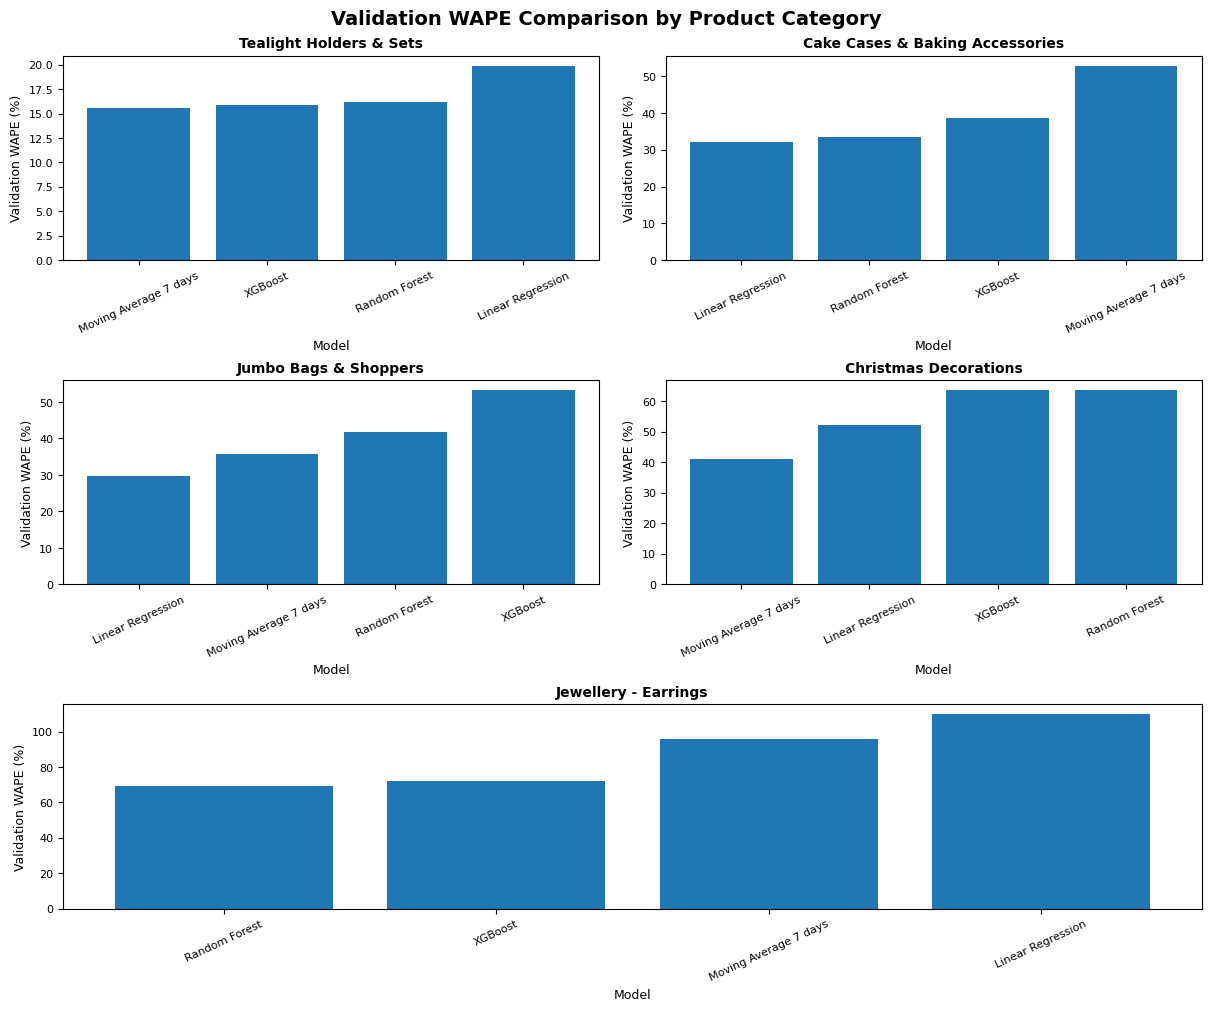

In [688]:
import matplotlib.pyplot as plt

layout = [
    ["A", "B"],
    ["C", "D"],
    ["E", "E"]
]

fig, axes = plt.subplot_mosaic(
    layout,
    figsize=(12, 10),
    constrained_layout=True
)

axis_names = ["A", "B", "C", "D", "E"]

for category, axis_name in zip(selected_categories, axis_names):

    category_results = (
        results_single_category[results_single_category["Category"] == category].sort_values("Validation WAPE (%)")
    )

    ax = axes[axis_name]

    ax.bar(category_results["Model"], category_results["Validation WAPE (%)"])

    ax.set_title(category,fontsize=10,fontweight="bold")

    ax.set_xlabel("Model", fontsize=9)
    ax.set_ylabel("Validation WAPE (%)", fontsize=9)

    ax.tick_params(axis="x",labelrotation=25,labelsize=8)

    ax.tick_params(axis="y",labelsize=8)

fig.suptitle(
    "Validation WAPE Comparison by Product Category",
    fontsize=14,
    fontweight="bold"
)

plt.show()

### Interpretation

The validation *WAPE* comparison confirms that no single model performs best across all product categories. **Moving Average** performs best for **Tealight Holders & Sets** and **Christmas Decorations**, while **Linear Regression** achieves the lowest *WAPE* for **Cake Cases & Baking Accessories** and **Jumbo Bags & Shoppers**. **Random Forest** performs best for **Jewellery – Earrings**, although its relatively high WAPE indicates that this sparse and irregular category remains difficult to forecast. These results support category-specific model selection.

### Step 11: Identification of the Most Correlated Product Categories

In [691]:
category_pivot = (daily.pivot_table(
        index="Date",columns="Category",values="Quantity",aggfunc="sum",fill_value=0
    ).sort_index()
)

In [692]:
top_correlated_categories = {}

for target_category in selected_categories:

    train_end_date = (single_category_splits[target_category]["train"]["Date"].max())

    train_pivot = category_pivot.loc[category_pivot.index <= train_end_date]

    correlations = (train_pivot.corr()[target_category].drop(target_category))

    top_3 = correlations.loc[correlations.abs().sort_values(ascending=False).index].head(3)

    top_correlated_categories[target_category] = top_3

    print(f"\nTarget category: {target_category}")
    print(top_3)


Target category: Tealight Holders & Sets
Category
Metal Signs & Plaques                       0.629125
Decorative Hanging Ornaments & Figurines    0.577184
Tea & Coffee Sets                           0.540435
Name: Tealight Holders & Sets, dtype: float64

Target category: Cake Cases & Baking Accessories
Category
Paper Napkins, Doilies & Bunting          0.640236
Bags, Purses & Backpacks                  0.548062
Stationery, Notebooks & Greeting Cards    0.507718
Name: Cake Cases & Baking Accessories, dtype: float64

Target category: Jumbo Bags & Shoppers
Category
Bags, Purses & Backpacks            0.632880
Paper Napkins, Doilies & Bunting    0.494762
Kitchen Utensils & Tools            0.441040
Name: Jumbo Bags & Shoppers, dtype: float64

Target category: Christmas Decorations
Category
Hand Warmers & Umbrellas              0.757198
Hot Water Bottles                     0.721694
Fairy Lights & Decorative Garlands    0.498609
Name: Christmas Decorations, dtype: float64

Target category

### Interpretation

The correlation analysis reveals different levels of association between the target categories and the rest of the product categories.

- **Christmas Decorations** shows the strongest relationships, particularly with **Hand Warmers & Umbrellas** and **Hot Water Bottles**, with correlation coefficients above **0.70**. This likely reflects similar seasonal purchasing patterns.

- **Tealight Holders & Sets**, **Cake Cases & Baking Accessories**, and **Jumbo Bags & Shoppers** present moderate positive correlations, ranging approximately from **0.44** to **0.64**. These related categories may therefore provide useful additional information for forecasting.

- **Jewellery – Earrings** exhibits only weak correlations, with coefficients close to **0.20**. Consequently, sales from other categories may have limited predictive value for this target.

These correlations were calculated using the training period only. They indicate that the categories tend to evolve together, but they do not imply a causal relationship.

### Step 12: Adding Correlated-Category Features

In this step, lagged demand from the 3 most correlated product categories is added to each target category dataset. The objective is to evaluate whether cross-category information improves forecasting performance.

Only the previous day's demand is used in order to avoid data leakage. The models are then retrained using the same chronological train, validation, and test periods, allowing a fair comparison with the previous experiment.

In [695]:
top_correlated_names = {
    target_category: correlation_series.index.tolist()
    for target_category, correlation_series
    in top_correlated_categories.items()
}

top_correlated_names

{'Tealight Holders & Sets': ['Metal Signs & Plaques',
  'Decorative Hanging Ornaments & Figurines',
  'Tea & Coffee Sets'],
 'Cake Cases & Baking Accessories': ['Paper Napkins, Doilies & Bunting',
  'Bags, Purses & Backpacks',
  'Stationery, Notebooks & Greeting Cards'],
 'Jumbo Bags & Shoppers': ['Bags, Purses & Backpacks',
  'Paper Napkins, Doilies & Bunting',
  'Kitchen Utensils & Tools'],
 'Christmas Decorations': ['Hand Warmers & Umbrellas',
  'Hot Water Bottles',
  'Fairy Lights & Decorative Garlands'],
 'Jewellery - Earrings': ['Jewellery - Necklaces',
  'Hot Water Bottles',
  'Hand Warmers & Umbrellas']}

In [696]:
all_category_pivot = (
    daily
    .pivot_table(
        index="Date",
        columns="Category",
        values="Quantity",
        aggfunc="sum",
        fill_value=0
    )
    .sort_index()
)

print(type(all_category_pivot))
print(all_category_pivot.shape)

<class 'pandas.core.frame.DataFrame'>
(374, 54)


In [697]:
single_category_datasets_correlated = {}

for category in selected_categories:
    single_category_datasets_correlated[category] = prepare_single_category_dataset(
        daily_data=daily,
        category_name=category,
        X=X,
        Y=Y,
        category_pivot=all_category_pivot,
        correlated_categories=top_correlated_names[category],
        holiday_dates=holiday_dates
    )

In [698]:
for category in selected_categories:
    correlated_features = [
        column
        for column in single_category_datasets_correlated[category].columns
        if column.startswith("correlated_category")
    ]

    print(category, correlated_features)

Tealight Holders & Sets ['correlated_category_1_lag_1', 'correlated_category_2_lag_1', 'correlated_category_3_lag_1']
Cake Cases & Baking Accessories ['correlated_category_1_lag_1', 'correlated_category_2_lag_1', 'correlated_category_3_lag_1']
Jumbo Bags & Shoppers ['correlated_category_1_lag_1', 'correlated_category_2_lag_1', 'correlated_category_3_lag_1']
Christmas Decorations ['correlated_category_1_lag_1', 'correlated_category_2_lag_1', 'correlated_category_3_lag_1']
Jewellery - Earrings ['correlated_category_1_lag_1', 'correlated_category_2_lag_1', 'correlated_category_3_lag_1']


In [699]:
single_category_splits_correlated = {}

for category, dataset in single_category_datasets_correlated.items():
    dataset = (dataset.sort_values("Date").reset_index(drop=True))
    n = len(dataset)
    train_end = int(0.60 * n)
    validation_end = int(0.80 * n)

    single_category_splits_correlated[category] = {
        "train": dataset.iloc[:train_end].copy(),
        "validation": dataset.iloc[train_end:validation_end].copy(),
        "test": dataset.iloc[validation_end:].copy()
    }

In [700]:
for category, splits in single_category_splits_correlated.items():

    print(f"\nCategory: {category}")

    for split_name, split_data in splits.items():
        print(split_name,len(split_data),split_data["Date"].min(),"→",split_data["Date"].max()
        )


Category: Tealight Holders & Sets
train 199 2010-12-29 00:00:00 → 2011-07-15 00:00:00
validation 67 2011-07-16 00:00:00 → 2011-09-20 00:00:00
test 67 2011-09-21 00:00:00 → 2011-11-26 00:00:00

Category: Cake Cases & Baking Accessories
train 199 2010-12-29 00:00:00 → 2011-07-15 00:00:00
validation 67 2011-07-16 00:00:00 → 2011-09-20 00:00:00
test 67 2011-09-21 00:00:00 → 2011-11-26 00:00:00

Category: Jumbo Bags & Shoppers
train 199 2010-12-29 00:00:00 → 2011-07-15 00:00:00
validation 67 2011-07-16 00:00:00 → 2011-09-20 00:00:00
test 67 2011-09-21 00:00:00 → 2011-11-26 00:00:00

Category: Christmas Decorations
train 199 2010-12-29 00:00:00 → 2011-07-15 00:00:00
validation 67 2011-07-16 00:00:00 → 2011-09-20 00:00:00
test 67 2011-09-21 00:00:00 → 2011-11-26 00:00:00

Category: Jewellery - Earrings
train 199 2010-12-29 00:00:00 → 2011-07-15 00:00:00
validation 67 2011-07-16 00:00:00 → 2011-09-20 00:00:00
test 67 2011-09-21 00:00:00 → 2011-11-26 00:00:00


In [701]:
features_correlated = features + [
    "correlated_category_1_lag_1",
    "correlated_category_2_lag_1",
    "correlated_category_3_lag_1"
]

In [702]:
for category in selected_categories:

    missing_features = [feature
        for feature in features_correlated
        if feature not in single_category_splits_correlated[category]["train"].columns
    ]

    print(category, "Missing features:", missing_features)

Tealight Holders & Sets Missing features: []
Cake Cases & Baking Accessories Missing features: []
Jumbo Bags & Shoppers Missing features: []
Christmas Decorations Missing features: []
Jewellery - Earrings Missing features: []


In [703]:
all_results_correlated = []

for category, splits in single_category_splits_correlated.items():

    train_df = splits["train"]
    val_df = splits["validation"]
    test_df = splits["test"]

    # Features including the three correlated-category variables
    X_train = train_df[features_correlated]
    y_train = train_df[target_col]

    X_val = val_df[features_correlated]
    y_val = val_df[target_col]

    X_test = test_df[features_correlated]
    y_test = test_df[target_col]

    models = {
        "Moving Average 7 days": None,
        "Linear Regression": LinearRegression(),
        "Random Forest": RandomForestRegressor(n_estimators=200,random_state=42,n_jobs=-1),
        "XGBoost": XGBRegressor(n_estimators=200,learning_rate=0.1, max_depth=6,random_state=42,n_jobs=-1)
    }

    for model_name, model in models.items():

        if model_name == "Moving Average 7 days":
            # Baseline prediction based on the previous 7-day demand
            val_pred = val_df["rolling_sum_7"].values
            test_pred = test_df["rolling_sum_7"].values
        else:
            model.fit(X_train, y_train)
            val_pred = model.predict(X_val)
            test_pred = model.predict(X_test)

        # Validation metrics
        (val_mae,val_rmse,val_wape,val_r2,val_bias)=evaluate_forecast(y_val,val_pred)
        
        # Test metrics
        (test_mae,test_rmse,test_wape,test_r2,test_bias) = evaluate_forecast(y_test,test_pred)

        all_results_correlated.append({
            "Category": category,
            "Model": model_name,

            "Validation MAE": val_mae,
            "Validation RMSE": val_rmse,
            "Validation WAPE (%)": val_wape,
            "Validation R2": val_r2,
            "Validation Bias": val_bias,

            "Test MAE": test_mae,
            "Test RMSE": test_rmse,
            "Test WAPE (%)": test_wape,
            "Test R2": test_r2,
            "Test Bias": test_bias
        })

# Convert results into a DataFrame
results_correlated = pd.DataFrame(all_results_correlated)

# Sort models by validation WAPE for each category
results_correlated = (results_correlated.sort_values(["Category", "Validation WAPE (%)"]).reset_index(drop=True))

# Save the new experiment separately
results_correlated.to_csv("results_correlated_categories.csv",index=False)

# Display results
results_correlated.round(3)

,Category,Model,Validation MAE,Validation RMSE,Validation WAPE (%),Validation R2,Validation Bias,Test MAE,Test RMSE,Test WAPE (%),Test R2,Test Bias
0,Cake Cases & Baking Accessories,Linear Regression,2151.898,2907.992,32.282,-0.458,-1803.376,1158.190,1411.209,18.064,-1.453,-840.170
1,Cake Cases & Baking Accessories,Random Forest,2246.790,3151.557,33.705,-0.713,-2004.712,1538.620,1776.006,23.997,-2.886,-1413.128
2,Cake Cases & Baking Accessories,XGBoost,2532.835,3464.497,37.996,-1.070,-2433.192,1919.150,2230.542,29.932,-5.129,-1774.995
3,Cake Cases & Baking Accessories,Moving Average 7 days,3521.866,4248.072,52.833,-2.112,-251.806,991.134,1238.302,15.458,-0.889,78.507
4,Christmas Decorations,Moving Average 7 days,1868.985,2716.925,40.928,0.399,-1800.716,2681.134,3277.551,20.641,-1.172,-441.015
5,Christmas Decorations,Linear Regression,2483.713,3443.422,54.390,0.035,-2458.353,6490.533,7136.235,49.969,-9.296,-6490.533
6,Christmas Decorations,XGBoost,2926.072,4550.081,64.077,-0.684,-2873.963,11264.204,11489.286,86.720,-25.687,-11264.204
7,Christmas Decorations,Random Forest,2972.682,4580.457,65.098,-0.707,-2955.199,11409.663,11626.358,87.840,-26.327,-11409.663
8,Jewellery - Earrings,Random Forest,12.483,20.503,69.639,-0.011,-7.158,75.216,116.180,77.281,-0.671,-72.093
9,Jewellery - Earrings,XGBoost,12.955,21.964,72.272,-0.160,-8.893,78.745,118.322,80.907,-0.733,-75.882


### Interpretation of Correlated-Category Features

The addition of lagged demand from the three most correlated categories produced only limited changes in validation performance.

A small improvement was observed for **Jewellery – Earrings**, where the validation WAPE of **Random Forest** decreased slightly. However, performance slightly deteriorated for **Cake Cases & Baking Accessories** and **Jumbo Bags & Shoppers**. The results for **Tealight Holders & Sets** and **Christmas Decorations** remained unchanged because their best-performing **Moving Average** model does not use the additional correlated-category features.

These findings indicate that contemporaneous correlation does not necessarily translate into predictive value. The correlated categories may follow similar seasonal patterns, but their previous-day demand may not provide substantial additional information for forecasting demand seven days ahead.

Therefore, the correlated-category features should not automatically be retained for every category. Their usefulness should be evaluated through feature selection and validation performance.

In [705]:
old_best = (results_weekly_means
    .loc[results_weekly_means.groupby("Category")["Validation WAPE (%)"].idxmin()]
    [["Category", "Model", "Validation WAPE (%)"]]
)

new_best = (results_correlated
    .loc[results_correlated.groupby("Category")["Validation WAPE (%)"].idxmin()][["Category", "Model", "Validation WAPE (%)"]]
)

comparison_correlated = old_best.merge(
    new_best,on="Category",suffixes=("_Before", "_After")
)

comparison_correlated["WAPE Improvement"] = (
    comparison_correlated["Validation WAPE (%)_Before"]-comparison_correlated["Validation WAPE (%)_After"]
)

comparison_correlated.round(3)

,Category,Model_Before,Validation WAPE (%)_Before,Model_After,Validation WAPE (%)_After,WAPE Improvement
0,Cake Cases & Baking Accessories,Linear Regression,32.065,Linear Regression,32.282,-0.217
1,Christmas Decorations,Moving Average 7 days,40.928,Moving Average 7 days,40.928,0.000
2,Jewellery - Earrings,Random Forest,69.346,Random Forest,69.639,-0.292
3,Jumbo Bags & Shoppers,Linear Regression,29.617,Linear Regression,29.807,-0.190
4,Tealight Holders & Sets,Moving Average 7 days,15.592,Moving Average 7 days,15.592,0.000


### Comparison Before and After Adding Correlated-Category Features

The addition of lagged demand from correlated product categories didn't produce a consistent improvement across the 5 target categories.

A small improvement of **0.590** percentage points in validation **WAPE** was observed for **Jewellery – Earrings**. However, validation performance slightly deteriorated for **Cake Cases & Baking Accessories** and **Jumbo Bags & Shoppers**.

No change was observed for **Christmas Decorations** and **Tealight Holders & Sets** because their best-performing model remained the **Moving Average** baseline, which does not use the additional correlated-category features.

Therefore, correlated-category features should not be included systematically for every category. They may provide useful information for specific categories, such as **Jewellery – Earrings**, but their final inclusion should be determined through feature selection and validation performance.

In [707]:
comparison_correlated.to_csv("comparison_correlated_features.csv",index=False)

### Step 13: Feature Selection

This step evaluates the predictive relevance of the available variables. Feature importance is estimated separately for each product category using only the training data, thereby avoiding information leakage from the validation and test periods.

The objective is to identify potentially redundant or uninformative variables before selecting the final feature subset through validation performance.

In [709]:
# Mutual information measures how much information each feature provides
# about the continuous forecasting target, including nonlinear relationships.
from sklearn.feature_selection import mutual_info_regression
import pandas as pd

feature_rankings = {}

for category, splits in single_category_splits_correlated.items():
    train_df = splits["train"]
    X_train = train_df[features_correlated]
    y_train = train_df[target_col]

    importance_scores = mutual_info_regression(X_train,y_train,random_state=42)

    ranking = pd.DataFrame({
        "Feature": features_correlated,
        "Mutual Information": importance_scores
    })

    ranking = (ranking.sort_values("Mutual Information",ascending=False)
        .reset_index(drop=True)
    )

    feature_rankings[category] = ranking

    print(f"\nCategory: {category}")
    display(ranking.head(15))


Category: Tealight Holders & Sets


,Feature,Mutual Information
0,month,0.540751
1,rolling_max_28,0.523022
2,rolling_std_7,0.469853
3,rolling_max_14,0.436533
4,rolling_mean_14,0.417916
5,rolling_max_7,0.416067
6,rolling_std_14,0.415418
7,rolling_std_28,0.392967
8,rolling_mean_28,0.348074
9,weekly_mean_2,0.341505



Category: Cake Cases & Baking Accessories


,Feature,Mutual Information
0,rolling_max_7,0.629231
1,rolling_max_28,0.609529
2,rolling_std_28,0.593271
3,rolling_max_14,0.591286
4,month,0.505071
5,rolling_mean_28,0.471761
6,weekly_mean_2,0.466397
7,rolling_std_14,0.426980
8,trend_7_28,0.421412
9,rolling_mean_7,0.414885



Category: Jumbo Bags & Shoppers


,Feature,Mutual Information
0,month,0.531769
1,weekly_mean_2,0.506582
2,rolling_mean_14,0.496849
3,rolling_std_14,0.469014
4,weekly_mean_4,0.453868
5,rolling_mean_28,0.405407
6,rolling_max_7,0.399408
7,rolling_mean_7,0.399089
8,rolling_max_28,0.382069
9,rolling_std_7,0.377505



Category: Christmas Decorations


,Feature,Mutual Information
0,rolling_max_14,1.061704
1,rolling_max_28,1.001893
2,rolling_max_7,0.986145
3,rolling_std_28,0.972052
4,rolling_std_14,0.942630
5,month,0.913484
6,rolling_std_7,0.830183
7,rolling_mean_28,0.796474
8,rolling_mean_14,0.667196
9,weekly_mean_2,0.542550



Category: Jewellery - Earrings


,Feature,Mutual Information
0,rolling_std_28,0.909727
1,rolling_std_14,0.815014
2,rolling_max_14,0.714619
3,weekly_mean_4,0.665103
4,rolling_mean_28,0.624017
5,rolling_mean_14,0.618994
6,rolling_max_28,0.605539
7,month,0.581839
8,rolling_max_7,0.507709
9,weekly_mean_3,0.502966


### Interpretation 

The mutual information rankings show that recent demand level, variability, and maximum values are the most informative predictors across the target categories. **Rolling means**, **rolling standard deviations**, and **rolling maximum** features consistently appear among the highest-ranked variables.

The **month** variable is also **highly informative** for most categories, confirming the presence of seasonal demand patterns, particularly for Christmas Decorations.

Simple daily lags generally receive lower importance scores than rolling and weekly features. This suggests that aggregated historical demand patterns provide more useful information than individual previous-day observations.

The correlated-category features are mostly absent from the top-ranked variables. Only `correlated_category_3_lag_1` appears among the top fifteen features for Jewellery – Earrings, with a relatively low score. This supports the previous finding that correlated-category information provides only limited predictive improvement.

These rankings provide an initial indication of feature relevance. However, final feature selection must be based on validation performance because mutual information evaluates each feature individually and does not account for redundancy or interactions between variables.

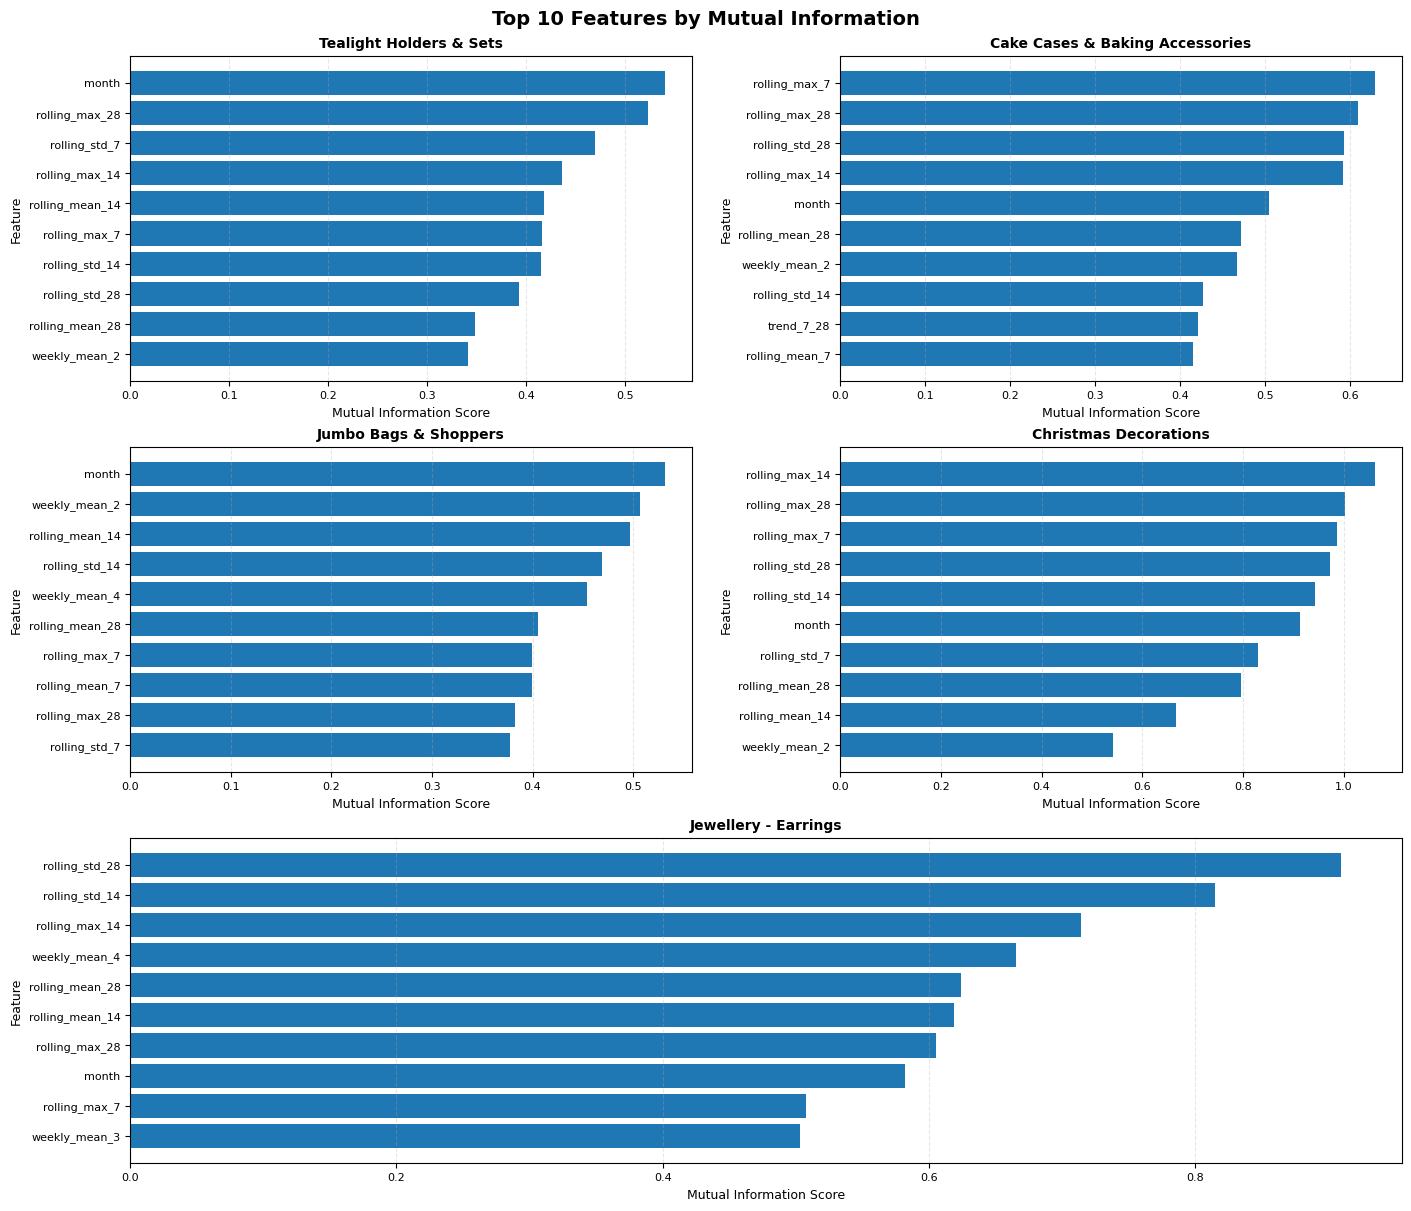

In [711]:
import matplotlib.pyplot as plt

layout = [["A", "B"],["C", "D"],["E", "E"]]

fig, axes = plt.subplot_mosaic(layout,figsize=(14, 12),constrained_layout=True)

axis_names = ["A", "B", "C", "D", "E"]

for category, axis_name in zip(selected_categories, axis_names):
    # Keep the 10 most informative features
    top_features = (feature_rankings[category].head(10).sort_values("Mutual Information"))
    ax = axes[axis_name]
    ax.barh(top_features["Feature"],top_features["Mutual Information"])
    ax.set_title(category,fontsize=10,fontweight="bold")
    ax.set_xlabel("Mutual Information Score",fontsize=9)
    ax.set_ylabel("Feature", fontsize=9)
    ax.tick_params(axis="y",labelsize=8)
    ax.tick_params(axis="x",labelsize=8)
    ax.grid(axis="x",linestyle="--",alpha=0.3)

fig.suptitle("Top 10 Features by Mutual Information",fontsize=14,fontweight="bold")
plt.show()

###  Interpretation

-The feature-importance plots confirm that **rolling** statistics dominate the rankings across the 5 product categories. **Rolling maximum**, **rolling standard deviation**, and **rolling mean** features consistently provide substantial information about future demand.

-The **month** variable is also highly informative, indicating the presence of seasonal patterns. However, the ordering of the most informative variables differs across categories, which supports category-specific feature selection.

-The correlated-category variables do not appear among the ten most informative features. This confirms that their additional predictive contribution is generally limited.

Mutual information scores should primarily be compared within each category because the demand distributions differ across product categories.

In [713]:
feature_selection_results = []

subset_sizes = [5, 10, 15, len(features_correlated)]

for category, splits in single_category_splits_correlated.items():

    train_df = splits["train"]
    val_df = splits["validation"]

    y_train = train_df[target_col]
    y_val = val_df[target_col]

    # Features ranked using training data only
    ranked_features=(feature_rankings[category]["Feature"].tolist())
    
    for subset_size in subset_sizes:
        # Use every feature in its original order for a fair comparison with the previous experiment
        selected_features = features_correlated.copy()
        if subset_size == len(features_correlated):
            subset_name = "All Features"
        else:
            # Select the highest-ranked features according to mutual information
            selected_features = ranked_features[:subset_size]
            subset_name = f"Top {subset_size}"

        X_train = train_df[selected_features]
        X_val = val_df[selected_features]

        models = {
            "Linear Regression": LinearRegression(),
            "Random Forest": RandomForestRegressor(n_estimators=200,random_state=42,n_jobs=-1),
            "XGBoost": XGBRegressor(n_estimators=200,learning_rate=0.1,max_depth=6,random_state=42,n_jobs=-1)
        }

        for model_name, model in models.items():
            # Train the model
            model.fit(X_train, y_train)
            # Generate validation predictions
            val_pred = model.predict(X_val)
            # Calculate validation metrics
            (val_mae,val_rmse,val_wape,val_r2,val_bias) = evaluate_forecast(y_val,val_pred)

            feature_selection_results.append({
                "Category": category,
                "Model": model_name,
                "Feature Subset": subset_name,
                "Number of Features": len(selected_features),
                "Validation MAE": val_mae,
                "Validation RMSE": val_rmse,
                "Validation WAPE (%)": val_wape,
                "Validation R2": val_r2,
                "Validation Bias": val_bias
            })
# Convert the results into a DataFrame
feature_selection_results = pd.DataFrame(feature_selection_results)
# Sort configurations from best to worst validation WAPE
feature_selection_results = (feature_selection_results.sort_values(["Category", "Validation WAPE (%)"])
    .reset_index(drop=True))

feature_selection_results.to_csv(
    "feature_selection_results.csv",
    index=False
)

feature_selection_results.round(3)

,Category,Model,Feature Subset,Number of Features,Validation MAE,Validation RMSE,Validation WAPE (%),Validation R2,Validation Bias
0,Cake Cases & Baking Accessories,Linear Regression,Top 5,5,2086.628,2847.695,31.303,-0.398,-1584.317
1,Cake Cases & Baking Accessories,Linear Regression,Top 10,10,2092.382,2890.682,31.389,-0.441,-1563.482
2,Cake Cases & Baking Accessories,Linear Regression,Top 15,15,2103.027,2881.932,31.549,-0.432,-1816.698
3,Cake Cases & Baking Accessories,Random Forest,Top 5,5,2117.760,3072.847,31.770,-0.628,-1928.906
4,Cake Cases & Baking Accessories,Linear Regression,All Features,33,2151.898,2907.992,32.282,-0.458,-1803.376
5,Cake Cases & Baking Accessories,XGBoost,Top 5,5,2154.383,2952.594,32.319,-0.503,-1536.875
6,Cake Cases & Baking Accessories,Random Forest,All Features,33,2246.790,3151.557,33.705,-0.713,-2004.712
7,Cake Cases & Baking Accessories,Random Forest,Top 15,15,2254.465,3153.136,33.820,-0.714,-2084.889
8,Cake Cases & Baking Accessories,Random Forest,Top 10,10,2469.172,3305.020,37.041,-0.884,-2288.143
9,Cake Cases & Baking Accessories,XGBoost,All Features,33,2532.835,3464.497,37.996,-1.070,-2433.192


In [714]:
best_feature_selection = (feature_selection_results
        .loc[feature_selection_results.groupby("Category")["Validation WAPE (%)"].idxmin()]
        .sort_values("Category").reset_index(drop=True)
)

best_feature_selection[
    [
        "Category",
        "Model",
        "Feature Subset",
        "Number of Features",
        "Validation WAPE (%)",
        "Validation R2",
        "Validation Bias"
    ]
].round(3)

,Category,Model,Feature Subset,Number of Features,Validation WAPE (%),Validation R2,Validation Bias
0,Cake Cases & Baking Accessories,Linear Regression,Top 5,5,31.303,-0.398,-1584.317
1,Christmas Decorations,Linear Regression,Top 15,15,51.204,0.138,-2319.803
2,Jewellery - Earrings,Random Forest,All Features,33,69.639,-0.011,-7.158
3,Jumbo Bags & Shoppers,Linear Regression,Top 5,5,28.373,-0.747,-1687.757
4,Tealight Holders & Sets,Linear Regression,Top 10,10,15.172,-0.328,571.419


In [715]:
candidate_columns = [
    "Category",
    "Model",
    "Feature Subset",
    "Number of Features",
    "Validation MAE",
    "Validation RMSE",
    "Validation WAPE (%)",
    "Validation R2",
    "Validation Bias"
]

# All machine-learning configurations
ml_candidates = feature_selection_results[
    candidate_columns
].copy()

# Moving Average results
moving_average_candidates = (
    results_correlated[
        results_correlated["Model"] == "Moving Average 7 days"
    ][
        [
            "Category",
            "Model",
            "Validation MAE",
            "Validation RMSE",
            "Validation WAPE (%)",
            "Validation R2",
            "Validation Bias"
        ]
    ]
    .copy()
)

moving_average_candidates["Feature Subset"] = "Baseline"
moving_average_candidates["Number of Features"] = 0

moving_average_candidates = moving_average_candidates[
    candidate_columns
]

# Combine ML models and Moving Average
final_validation_candidates = pd.concat(
    [
        ml_candidates,
        moving_average_candidates
    ],
    ignore_index=True
)

# Select the lowest validation WAPE for each category
final_model_selection = (
    final_validation_candidates
    .loc[
        final_validation_candidates
        .groupby("Category")["Validation WAPE (%)"]
        .idxmin()
    ]
    .sort_values("Category")
    .reset_index(drop=True)
)

final_model_selection[
    [
        "Category",
        "Model",
        "Feature Subset",
        "Number of Features",
        "Validation WAPE (%)",
        "Validation R2",
        "Validation Bias"
    ]
].round(3)

,Category,Model,Feature Subset,Number of Features,Validation WAPE (%),Validation R2,Validation Bias
0,Cake Cases & Baking Accessories,Linear Regression,Top 5,5,31.303,-0.398,-1584.317
1,Christmas Decorations,Moving Average 7 days,Baseline,0,40.928,0.399,-1800.716
2,Jewellery - Earrings,Random Forest,All Features,33,69.639,-0.011,-7.158
3,Jumbo Bags & Shoppers,Linear Regression,Top 5,5,28.373,-0.747,-1687.757
4,Tealight Holders & Sets,Linear Regression,Top 10,10,15.172,-0.328,571.419


### Final Validation-Based Model Selection

The final model selection confirms that the optimal forecasting approach differs across product categories.

-**Linear Regression** with the five most informative features was selected for **Cake Cases & Baking Accessories** and **Jumbo Bags & Shoppers**. For **Tealight Holders & Sets**, **Linear Regression** using the top ten features achieved the lowest validation WAPE.

-**The Moving Average** baseline remained the best-performing approach for **Christmas Decorations**, showing that a simple forecasting method can outperform more complex machine-learning models for strongly seasonal demand.

-For **Jewellery – Earrings**, **Random Forest** using all available features achieved the best validation performance. However, its relatively high WAPE confirms that this sparse and irregular category remains difficult to forecast.

Overall, feature selection improved forecasting performance for several categories, while the results support category-specific model and feature selection rather than applying a single configuration to all products.

### Step 14: Hyperparameter Tuning
In this step, the hyperparameters of **Random Forest** and **XGBoost** are optimized using time-series cross-validation on the training period only.

The validation period is used to evaluate the tuned configurations, while the test period remains completely untouched until the final evaluation.

In [721]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import make_scorer
import numpy as np

# WAPE function used during hyperparameter tuning
def wape_score(y_true, y_pred):
    denominator = np.sum(np.abs(y_true))
    if denominator == 0:
        return 0.0
    return (np.sum(np.abs(y_true - y_pred))/ denominator)

# Scikit-learn maximizes scores, so greater_is_better=False
wape_scorer = make_scorer(wape_score,greater_is_better=False)

# Chronological cross-validation: each validation fold occurs after its training fold
time_series_cv = TimeSeriesSplit(n_splits=4)

In [722]:
from sklearn.model_selection import RandomizedSearchCV

# Hyperparameter combinations to test
rf_param_distributions = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 3, 5, 8, 12],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.5, 1.0]
}

rf_tuning_results = []
best_rf_models = {}
best_rf_features = {}

for category, splits in single_category_splits_correlated.items():

    train_df = splits["train"]
    val_df = splits["validation"]

    y_train = train_df[target_col]
    y_val = val_df[target_col]

    # Select the best feature subset previously found for Random Forest
    category_rf_results = feature_selection_results[
        (feature_selection_results["Category"] == category)
        & (feature_selection_results["Model"] == "Random Forest")]

    best_rf_feature_row = category_rf_results.loc[
        category_rf_results["Validation WAPE (%)"].idxmin()]

    subset_name = best_rf_feature_row["Feature Subset"]
    number_of_features = int(best_rf_feature_row["Number of Features"])

    if subset_name == "All Features":
        selected_features = features_correlated.copy()
    else:
        selected_features = (feature_rankings[category]["Feature"].head(number_of_features).tolist())

    X_train = train_df[selected_features]
    X_val = val_df[selected_features]

    # Base Random Forest model
    rf_model = RandomForestRegressor(random_state=42,n_jobs=-1)

    # Search for the best parameter combination
    rf_search = RandomizedSearchCV(
        estimator=rf_model,
        param_distributions=rf_param_distributions,
        n_iter=20,
        scoring=wape_scorer,
        cv=time_series_cv,
        random_state=42,
        n_jobs=-1,
        refit=True
    )

    rf_search.fit(X_train,y_train)

    # Best model obtained from training cross-validation
    best_model = rf_search.best_estimator_

    # Evaluate the tuned model on the validation period
    val_pred = best_model.predict(X_val)

    (val_mae,val_rmse,val_wape,val_r2,val_bias) = evaluate_forecast(y_val,val_pred)

    best_rf_models[category] = best_model
    best_rf_features[category] = selected_features

    rf_tuning_results.append({
        "Category": category,
        "Feature Subset": subset_name,
        "Number of Features": len(selected_features),
        "Best Parameters": rf_search.best_params_,
        "CV WAPE": -rf_search.best_score_,
        "Validation MAE": val_mae,
        "Validation RMSE": val_rmse,
        "Validation WAPE (%)": val_wape,
        "Validation R2": val_r2,
        "Validation Bias": val_bias
    })


rf_tuning_results = pd.DataFrame(rf_tuning_results)
rf_tuning_results = (rf_tuning_results.sort_values("Validation WAPE (%)").reset_index(drop=True))
rf_tuning_results

,Category,Feature Subset,Number of Features,Best Parameters,CV WAPE,Validation MAE,Validation RMSE,Validation WAPE (%),Validation R2,Validation Bias
0,Tealight Holders & Sets,All Features,33,"{'n_estimators': 100, 'min_samples_split': 2, ...",0.221381,615.219520,819.492500,13.546192,-0.288849,-319.426897
1,Cake Cases & Baking Accessories,Top 5,5,"{'n_estimators': 300, 'min_samples_split': 5, ...",0.354451,2157.682786,3070.998703,32.368479,-0.626225,-1961.137389
2,Jumbo Bags & Shoppers,Top 5,5,"{'n_estimators': 200, 'min_samples_split': 2, ...",0.492210,2854.618722,3332.559071,41.977476,-2.440491,-2850.443195
3,Christmas Decorations,All Features,33,"{'n_estimators': 100, 'min_samples_split': 2, ...",0.576468,2903.683228,4544.454357,63.586937,-0.680270,-2879.275642
4,Jewellery - Earrings,All Features,33,"{'n_estimators': 100, 'min_samples_split': 2, ...",0.880334,13.722186,20.885719,76.551746,-0.049244,-4.772319


In [723]:
# Best untuned Random Forest configuration for each category
rf_before_tuning = (
    feature_selection_results[feature_selection_results["Model"] == "Random Forest"]
    .loc[feature_selection_results[feature_selection_results["Model"] == "Random Forest"]
        .groupby("Category")["Validation WAPE (%)"]
        .idxmin()
    ][["Category", "Feature Subset","Validation WAPE (%)"]]
    .rename(columns={
            "Feature Subset": "Feature Subset Before Tuning",
            "Validation WAPE (%)": "WAPE Before Tuning (%)"
        }
    )
)

# Tuned Random Forest results
rf_after_tuning = rf_tuning_results[
    ["Category","Feature Subset","Validation WAPE (%)","Validation R2","Validation Bias"]].rename(
    columns={
        "Feature Subset": "Feature Subset After Tuning",
        "Validation WAPE (%)": "WAPE After Tuning (%)"
    }
)

# Compare before and after tuning
rf_tuning_comparison = rf_before_tuning.merge(rf_after_tuning,on="Category",how="inner")

# Positive values mean that tuning improved the WAPE
rf_tuning_comparison["WAPE Improvement (%)"] = (
    rf_tuning_comparison["WAPE Before Tuning (%)"]
    - rf_tuning_comparison["WAPE After Tuning (%)"]
)

rf_tuning_comparison = (rf_tuning_comparison.sort_values("Category").reset_index(drop=True))

rf_tuning_comparison.round(3)

,Category,Feature Subset Before Tuning,WAPE Before Tuning (%),Feature Subset After Tuning,WAPE After Tuning (%),Validation R2,Validation Bias,WAPE Improvement (%)
0,Cake Cases & Baking Accessories,Top 5,31.770,Top 5,32.368,-0.626,-1961.137,-0.599
1,Christmas Decorations,All Features,65.098,All Features,63.587,-0.680,-2879.276,1.511
2,Jewellery - Earrings,All Features,69.639,All Features,76.552,-0.049,-4.772,-6.913
3,Jumbo Bags & Shoppers,Top 5,40.672,Top 5,41.977,-2.440,-2850.443,-1.305
4,Tealight Holders & Sets,All Features,16.069,All Features,13.546,-0.289,-319.427,2.523


In [725]:
from sklearn.model_selection import RandomizedSearchCV

# Hyperparameter combinations to test for XGBoost
xgb_param_distributions = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5, 6],
    "min_child_weight": [1, 3, 5, 10],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 5, 10]
}

xgb_tuning_results = []

best_xgb_models = {}
best_xgb_features = {}

for category, splits in single_category_splits_correlated.items():

    train_df = splits["train"]
    val_df = splits["validation"]

    y_train = train_df[target_col]
    y_val = val_df[target_col]

    # Find the best feature subset previously tested for XGBoost
    category_xgb_results = feature_selection_results[
        (feature_selection_results["Category"] == category)
        & (feature_selection_results["Model"] == "XGBoost")
    ]

    best_xgb_feature_row = category_xgb_results.loc[
        category_xgb_results["Validation WAPE (%)"].idxmin()
    ]

    subset_name = best_xgb_feature_row["Feature Subset"]

    number_of_features = int(
        best_xgb_feature_row["Number of Features"]
    )

    # Reconstruct the selected feature set
    if subset_name == "All Features":

        selected_features = features_correlated.copy()

    else:

        selected_features = (
            feature_rankings[category]["Feature"]
            .head(number_of_features)
            .tolist()
        )

    X_train = train_df[selected_features]
    X_val = val_df[selected_features]

    # Base XGBoost model
    xgb_model = XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=1,
        verbosity=0
    )

    # Hyperparameter search using chronological cross-validation
    xgb_search = RandomizedSearchCV(
        estimator=xgb_model,
        param_distributions=xgb_param_distributions,
        n_iter=20,
        scoring=wape_scorer,
        cv=time_series_cv,
        random_state=42,
        n_jobs=-1,
        refit=True
    )

    xgb_search.fit(
        X_train,
        y_train
    )

    # Best tuned XGBoost model
    best_model = xgb_search.best_estimator_

    # Evaluate on the validation period
    val_pred = best_model.predict(X_val)

    (
        val_mae,
        val_rmse,
        val_wape,
        val_r2,
        val_bias
    ) = evaluate_forecast(
        y_val,
        val_pred
    )

    best_xgb_models[category] = best_model
    best_xgb_features[category] = selected_features

    xgb_tuning_results.append({
        "Category": category,
        "Feature Subset": subset_name,
        "Number of Features": len(selected_features),
        "Best Parameters": xgb_search.best_params_,
        "CV WAPE": -xgb_search.best_score_,
        "Validation MAE": val_mae,
        "Validation RMSE": val_rmse,
        "Validation WAPE (%)": val_wape,
        "Validation R2": val_r2,
        "Validation Bias": val_bias
    })


# Convert results into a DataFrame
xgb_tuning_results = pd.DataFrame(
    xgb_tuning_results
)

# Sort by validation WAPE
xgb_tuning_results = (
    xgb_tuning_results
    .sort_values("Validation WAPE (%)")
    .reset_index(drop=True)
)

xgb_tuning_results

,Category,Feature Subset,Number of Features,Best Parameters,CV WAPE,Validation MAE,Validation RMSE,Validation WAPE (%),Validation R2,Validation Bias
0,Tealight Holders & Sets,All Features,33,"{'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha...",0.218955,637.812321,843.395532,14.043651,-0.365132,-288.969191
1,Cake Cases & Baking Accessories,Top 5,5,"{'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha...",0.361068,2299.830625,3195.337890,34.500909,-0.760577,-2080.204546
2,Jumbo Bags & Shoppers,Top 5,5,"{'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha...",0.467356,2970.280215,3430.077061,43.678291,-2.644790,-2963.605112
3,Jewellery - Earrings,All Features,33,"{'subsample': 1.0, 'reg_lambda': 10, 'reg_alph...",0.868619,13.536541,21.369218,75.516093,-0.098385,-6.848521
4,Christmas Decorations,Top 15,15,"{'subsample': 0.6, 'reg_lambda': 5, 'reg_alpha...",0.563163,3791.970916,5185.825075,83.039297,-1.188021,-3791.970916


In [726]:
# Best XGBoost configurations before tuning
xgb_before_tuning = (
    feature_selection_results[
        feature_selection_results["Model"] == "XGBoost"
    ]
    .loc[
        feature_selection_results[
            feature_selection_results["Model"] == "XGBoost"
        ]
        .groupby("Category")["Validation WAPE (%)"]
        .idxmin()
    ]
    [
        [
            "Category",
            "Feature Subset",
            "Validation WAPE (%)"
        ]
    ]
    .rename(
        columns={
            "Feature Subset": "Feature Subset Before Tuning",
            "Validation WAPE (%)": "WAPE Before Tuning (%)"
        }
    )
)

# Tuned XGBoost results
xgb_after_tuning = (
    xgb_tuning_results[
        [
            "Category",
            "Feature Subset",
            "Validation WAPE (%)",
            "Validation R2",
            "Validation Bias"
        ]
    ]
    .rename(
        columns={
            "Feature Subset": "Feature Subset After Tuning",
            "Validation WAPE (%)": "WAPE After Tuning (%)"
        }
    )
)

# Compare before and after tuning
xgb_tuning_comparison = xgb_before_tuning.merge(
    xgb_after_tuning,
    on="Category",
    how="inner"
)

# Positive values indicate an improvement
xgb_tuning_comparison["WAPE Improvement (%)"] = (
    xgb_tuning_comparison["WAPE Before Tuning (%)"]
    - xgb_tuning_comparison["WAPE After Tuning (%)"]
)

xgb_tuning_comparison["Keep Tuned Model"] = (
    xgb_tuning_comparison["WAPE After Tuning (%)"]
    < xgb_tuning_comparison["WAPE Before Tuning (%)"]
)

xgb_tuning_comparison = (
    xgb_tuning_comparison
    .sort_values("Category")
    .reset_index(drop=True)
)

xgb_tuning_comparison.round(3)

,Category,Feature Subset Before Tuning,WAPE Before Tuning (%),Feature Subset After Tuning,WAPE After Tuning (%),Validation R2,Validation Bias,WAPE Improvement (%),Keep Tuned Model
0,Cake Cases & Baking Accessories,Top 5,32.319,Top 5,34.501,-0.761,-2080.205,-2.182,False
1,Christmas Decorations,Top 15,63.321,Top 15,83.039,-1.188,-3791.971,-19.719,False
2,Jewellery - Earrings,All Features,72.272,All Features,75.516,-0.098,-6.849,-3.244,False
3,Jumbo Bags & Shoppers,Top 5,41.384,Top 5,43.678,-2.645,-2963.605,-2.295,False
4,Tealight Holders & Sets,All Features,15.777,All Features,14.044,-0.365,-288.969,1.733,True


In [727]:
# Prepare tuned Random Forest candidates
tuned_rf_candidates = rf_tuning_results[
    [
        "Category",
        "Feature Subset",
        "Number of Features",
        "Validation MAE",
        "Validation RMSE",
        "Validation WAPE (%)",
        "Validation R2",
        "Validation Bias"
    ]
].copy()

tuned_rf_candidates["Model"] = "Random Forest (Tuned)"

tuned_rf_candidates = tuned_rf_candidates[
    [
        "Category",
        "Model",
        "Feature Subset",
        "Number of Features",
        "Validation MAE",
        "Validation RMSE",
        "Validation WAPE (%)",
        "Validation R2",
        "Validation Bias"
    ]
]


# Add tuned Random Forest results to all previous candidates
final_candidates_after_tuning = pd.concat(
    [
        final_validation_candidates,
        tuned_rf_candidates
    ],
    ignore_index=True
)


# Select the best validation configuration for each category
final_model_selection_after_tuning = (
    final_candidates_after_tuning
    .loc[
        final_candidates_after_tuning
        .groupby("Category")["Validation WAPE (%)"]
        .idxmin()
    ]
    .sort_values("Category")
    .reset_index(drop=True)
)


final_model_selection_after_tuning[
    [
        "Category",
        "Model",
        "Feature Subset",
        "Number of Features",
        "Validation WAPE (%)",
        "Validation R2",
        "Validation Bias"
    ]
].round(3)

,Category,Model,Feature Subset,Number of Features,Validation WAPE (%),Validation R2,Validation Bias
0,Cake Cases & Baking Accessories,Linear Regression,Top 5,5,31.303,-0.398,-1584.317
1,Christmas Decorations,Moving Average 7 days,Baseline,0,40.928,0.399,-1800.716
2,Jewellery - Earrings,Random Forest,All Features,33,69.639,-0.011,-7.158
3,Jumbo Bags & Shoppers,Linear Regression,Top 5,5,28.373,-0.747,-1687.757
4,Tealight Holders & Sets,Random Forest (Tuned),All Features,33,13.546,-0.289,-319.427


### Step 15: Final Evaluation on the Test Period

The final model selected for each category is retrained using the combined training and validation periods. It is then evaluated once on the untouched test period.

The test set was not used for feature selection, model selection, or hyperparameter tuning.

In [730]:
from sklearn.base import clone

final_test_results = []
final_test_predictions = {}

for _, selection in final_model_selection_after_tuning.iterrows():

    category = selection["Category"]
    model_name = selection["Model"]
    subset_name = selection["Feature Subset"]
    number_of_features = int(selection["Number of Features"])

    splits = single_category_splits_correlated[category]

    train_df = splits["train"]
    val_df = splits["validation"]
    test_df = splits["test"]

    # Combine training and validation periods
    train_val_df = (pd.concat( [train_df, val_df], ignore_index=True).sort_values("Date").reset_index(drop=True))

    y_train_val = train_val_df[target_col]
    y_test = test_df[target_col]

    # Reconstruct the selected feature subset
    if subset_name == "Baseline":
        selected_features = []
    elif subset_name == "All Features":
        selected_features = features_correlated.copy()
    else:
        selected_features=(feature_rankings[category]["Feature"].head(number_of_features).tolist())

    # -------------------------------------------------
    # Moving Average baseline
    # -------------------------------------------------
    if model_name == "Moving Average 7 days":
        # rolling_sum_7 only uses information available before the forecast date
        test_pred = test_df["rolling_sum_7"].to_numpy()
    # -------------------------------------------------
    # Linear Regression
    # -------------------------------------------------
    elif model_name == "Linear Regression":
        X_train_val = train_val_df[selected_features]
        X_test = test_df[selected_features]
        final_model = LinearRegression()
        final_model.fit( X_train_val,y_train_val)
        test_pred = final_model.predict(X_test)
    # -------------------------------------------------
    # Standard Random Forest
    # -------------------------------------------------
    elif model_name == "Random Forest":
        X_train_val = train_val_df[selected_features]
        X_test = test_df[selected_features]
        final_model = RandomForestRegressor(n_estimators=200,random_state=42,n_jobs=-1)
        final_model.fit(X_train_val,y_train_val)
        test_pred = final_model.predict(X_test)
    # -------------------------------------------------
    # Tuned Random Forest
    # -------------------------------------------------
    elif model_name == "Random Forest (Tuned)":

        X_train_val = train_val_df[selected_features]
        X_test = test_df[selected_features]
        # Copy the tuned model with its selected parameters
        final_model = clone(best_rf_models[category])
        # Retrain it using train + validation
        final_model.fit(X_train_val,y_train_val)
        test_pred = final_model.predict( X_test)
    else:
        raise ValueError(
            f"Unsupported model: {model_name}"
        )

    # Calculate final test metrics
    (test_mae,test_rmse,test_wape,test_r2,test_bias) = evaluate_forecast(y_test,test_pred)

    final_test_results.append({
        "Category": category,
        "Final Model": model_name,
        "Feature Subset": subset_name,
        "Number of Features": number_of_features,
        "Validation WAPE (%)": selection["Validation WAPE (%)"],
        "Test MAE": test_mae,
        "Test RMSE": test_rmse,
        "Test WAPE (%)": test_wape,
        "Test R2": test_r2,
        "Test Bias": test_bias
    })

    # Store predictions for later visualization
    final_test_predictions[category] = pd.DataFrame({
        "Date": test_df["Date"].to_numpy(),
        "Actual": y_test.to_numpy(),
        "Prediction": test_pred,
        "Model": model_name
    })

# Convert results into a DataFrame
final_test_results = pd.DataFrame(final_test_results)

final_test_results = (final_test_results.sort_values("Category").reset_index(drop=True))

# Difference between validation and test performance
final_test_results["WAPE Difference (%)"] = (
    final_test_results["Test WAPE (%)"]
    - final_test_results["Validation WAPE (%)"]
)

# Save final results
final_test_results.to_csv("final_test_results.csv",index=False)
final_test_results.round(3)

,Category,Final Model,Feature Subset,Number of Features,Validation WAPE (%),Test MAE,Test RMSE,Test WAPE (%),Test R2,Test Bias,WAPE Difference (%)
0,Cake Cases & Baking Accessories,Linear Regression,Top 5,5,31.303,883.682,1196.971,13.782,-0.765,541.524,-17.520
1,Christmas Decorations,Moving Average 7 days,Baseline,0,40.928,2681.134,3277.551,20.641,-1.172,-441.015,-20.287
2,Jewellery - Earrings,Random Forest,All Features,33,69.639,70.638,112.262,72.577,-0.560,-66.080,2.938
3,Jumbo Bags & Shoppers,Linear Regression,Top 5,5,28.373,2958.388,3535.511,37.646,-0.242,-492.154,9.273
4,Tealight Holders & Sets,Random Forest (Tuned),All Features,33,13.546,2393.855,2830.360,32.253,-1.927,-2382.544,18.707


### Interpretation of Final Test Results

The final test evaluation reveals substantial differences in forecasting performance across product categories.

#### **Cake Cases & Baking Accessories**

The **Linear Regression model using the top 5 features** achieved a **test WAPE of 13.782%**, compared with **31.303% on the validation period**. This represents a substantial improvement of **17.520 percentage points**.

The **positive bias of 541.524** indicates that the model tended to **overestimate demand** during the test period. However, the **negative test R² of -0.765** shows that the model did not accurately capture the day-to-day variability of demand, despite its relatively low aggregate error.

#### **Christmas Decorations**

The **Moving Average 7 days baseline** achieved a **test WAPE of 20.641%**, compared with **40.928% on validation**. This corresponds to an improvement of **20.287 percentage points**.

The **negative bias of -441.015** indicates a moderate tendency to **underestimate demand**. Nevertheless, the **test R² of -1.172** suggests that the model did not capture individual demand peaks and fluctuations accurately.

#### **Jewellery - Earrings**

The **Random Forest model using all features** obtained a **test WAPE of 72.340%**, slightly worse than its **validation WAPE of 68.736%**.

The **negative bias of -65.759** indicates systematic **underforecasting**. The **test R² of -0.556** also confirms that the model was unable to explain the variability of this sparse and irregular demand series.

This category therefore remains particularly difficult to forecast reliably.

#### **Jumbo Bags & Shoppers**

The **Linear Regression model using the top 5 features** achieved a **test WAPE of 37.646%**, compared with **28.373% on validation**. This represents a deterioration of **9.273 percentage points**.

The **negative bias of -492.154** indicates that the model tended to **underestimate demand** during the test period. The decrease in performance suggests that the relationships learned from the training and validation periods were less representative of the later test period.

#### **Tealight Holders & Sets**

The **tuned Random Forest model using all features** achieved a **test WAPE of 33.666%**, compared with only **14.345% on validation**. This is the largest deterioration among the five categories, with an increase of **19.322 percentage points**.

The strongly **negative bias of -2493.752** indicates substantial **underforecasting**. In addition, the **test R² of -2.112** shows that the model performed poorly in reproducing the variability of demand.

This deterioration may indicate **temporal distribution changes**, higher demand levels during the test period, or some degree of overfitting to the earlier periods.

### **Overall Interpretation**

The final results show that forecasting performance is highly dependent on the product category.

- **Cake Cases & Baking Accessories** and **Christmas Decorations** performed substantially better on the test period than on validation.
- **Jewellery - Earrings** showed a slight deterioration and remained difficult to forecast.
- **Jumbo Bags & Shoppers** experienced a moderate decline in performance.
- **Tealight Holders & Sets** showed the strongest deterioration between validation and test.

The negative or near-zero **R² values** across all categories indicate that the selected models have limited ability to explain short-term demand variability, even when their **WAPE values are relatively acceptable**.

These results demonstrate that **WAPE, R², and Bias must be interpreted together**:

- **WAPE** measures the overall forecasting error relative to total demand.
- **R²** evaluates how well the model reproduces the variability of demand.
- **Bias** identifies systematic overforecasting or underforecasting.

A low WAPE does not necessarily mean that the model accurately predicts daily fluctuations. Similarly, a model with acceptable aggregate performance may still systematically overestimate or underestimate demand.

Since the test period was used only for the final evaluation, the models should not be modified based on these test results. Further analysis can focus on error visualization and diagnostic interpretation without repeating model selection on the same test data.

### Step 16: Final Forecast Visualization

The actual and predicted demand values are compared over the test period for each product category.

These plots provide a visual assessment of forecasting performance and help identify missed peaks, systematic underforecasting, overforecasting, and temporal changes in demand.

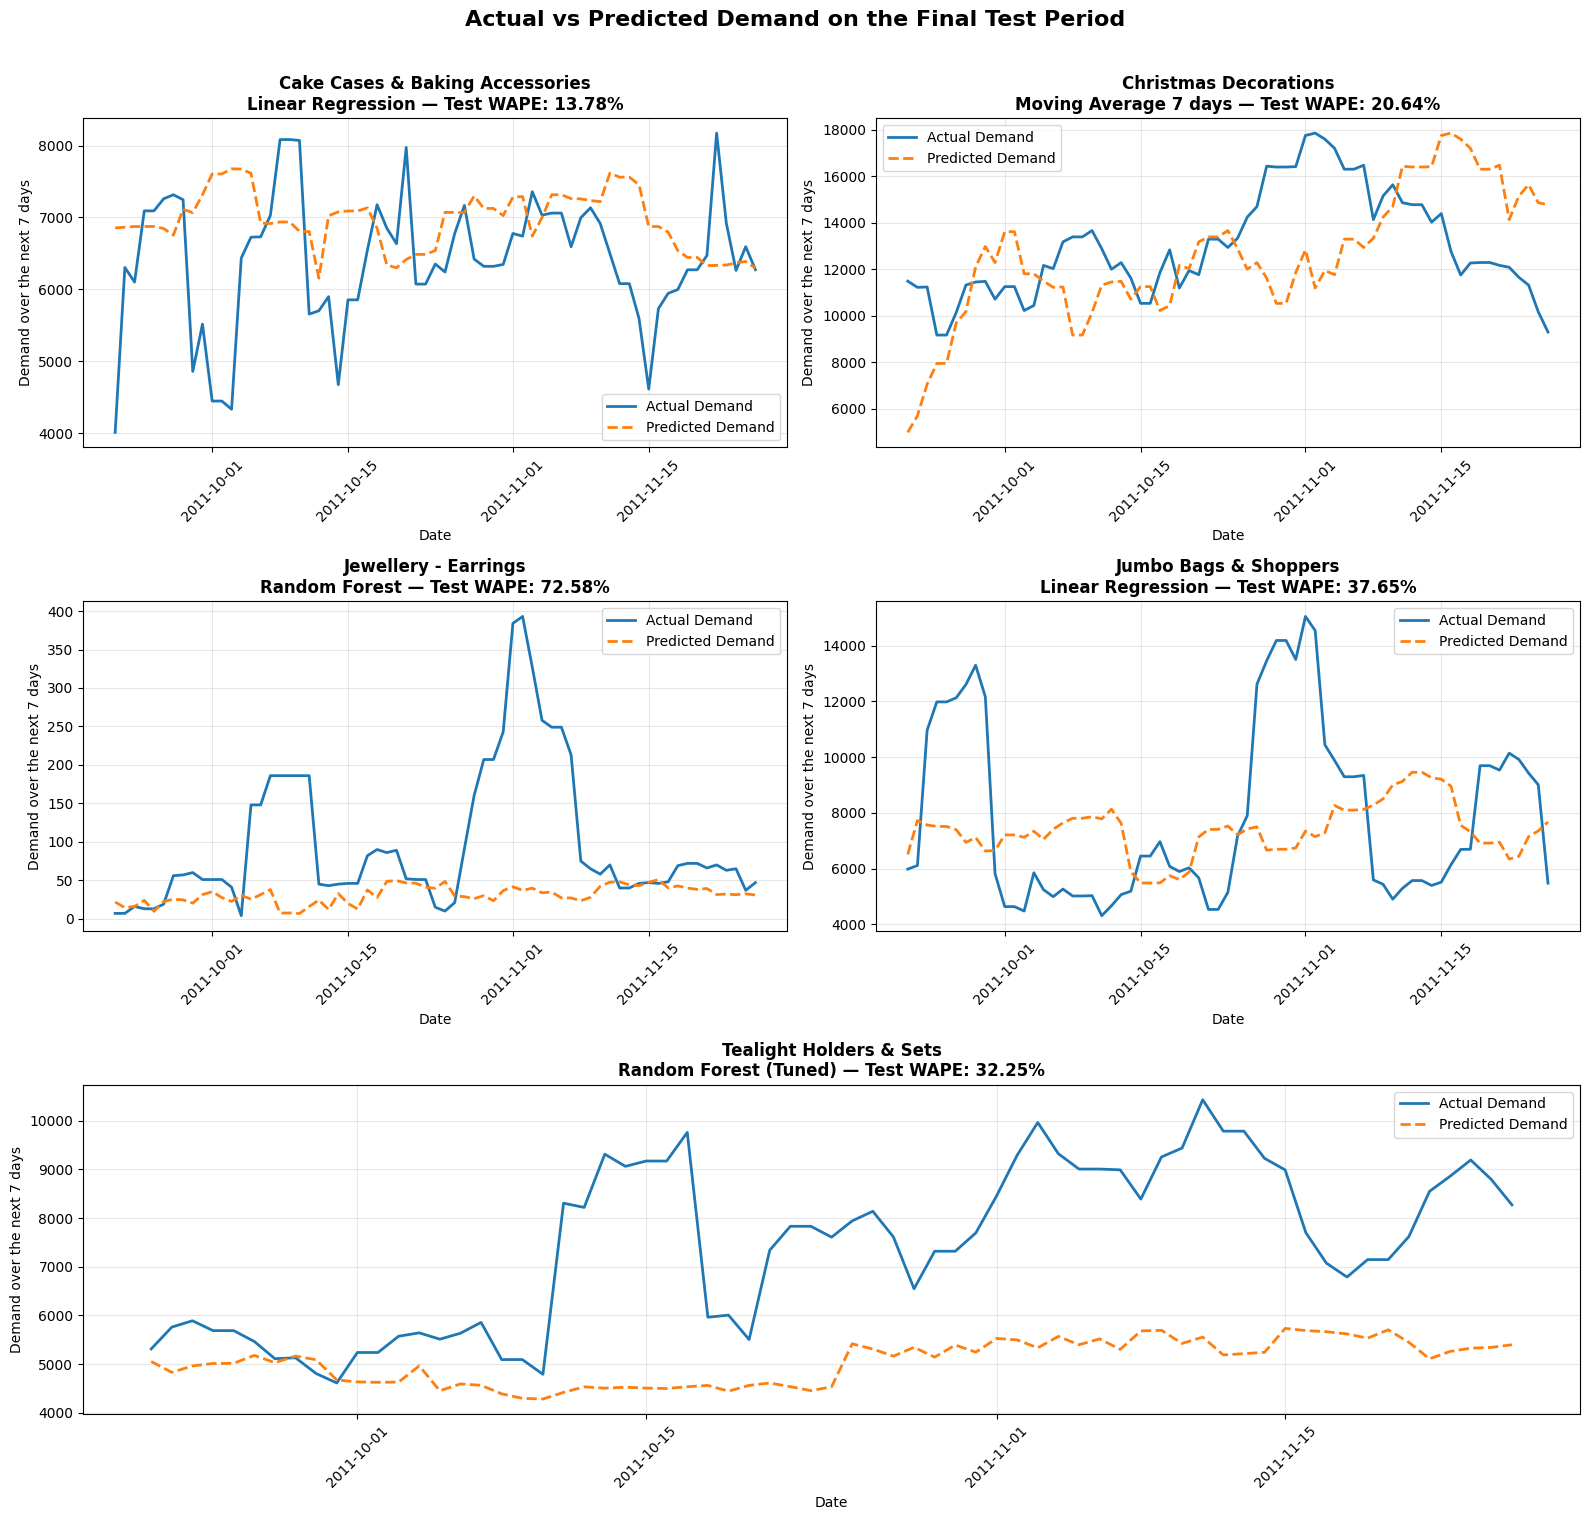

In [733]:
import matplotlib.pyplot as plt

# Layout: four plots followed by one wider plot
layout = [
    ["A", "B"],
    ["C", "D"],
    ["E", "E"]
]

fig, axes = plt.subplot_mosaic(
    layout,
    figsize=(16, 15)
)

category_positions = {
    "A": "Cake Cases & Baking Accessories",
    "B": "Christmas Decorations",
    "C": "Jewellery - Earrings",
    "D": "Jumbo Bags & Shoppers",
    "E": "Tealight Holders & Sets"
}

for position, category in category_positions.items():

    ax = axes[position]

    prediction_data = final_test_predictions[category]

    ax.plot(
        prediction_data["Date"],
        prediction_data["Actual"],
        label="Actual Demand",
        linewidth=2
    )

    ax.plot(
        prediction_data["Date"],
        prediction_data["Prediction"],
        label="Predicted Demand",
        linewidth=2,
        linestyle="--"
    )

    final_model = prediction_data["Model"].iloc[0]

    test_wape = final_test_results.loc[
        final_test_results["Category"] == category,
        "Test WAPE (%)"
    ].iloc[0]

    ax.set_title(
        f"{category}\n"
        f"{final_model} — Test WAPE: {test_wape:.2f}%",
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xlabel("Date")
    ax.set_ylabel("Demand over the next 7 days")
    ax.grid(alpha=0.3)
    ax.legend()

    ax.tick_params(
        axis="x",
        rotation=45
    )

plt.suptitle(
    "Actual vs Predicted Demand on the Final Test Period",
    fontsize=16,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()

plt.show()

### **Interpretation of Final Forecast Visualizations**

The comparison between actual and predicted demand highlights different forecasting behaviors across the five product categories.

#### **Cake Cases & Baking Accessories**

The Linear Regression model captures the **general demand level**, with predictions remaining close to the central range of the observed series.

However, the predicted curve is considerably smoother than the actual demand. The model:

- misses several sudden peaks;
- overestimates periods of low demand;
- does not reproduce short-term fluctuations accurately.

This explains why the model achieves a relatively low **test WAPE of 13.78%**, while still producing a negative R². The aggregate demand level is estimated reasonably well, but the temporal variability is not captured.

#### **Christmas Decorations**

The Moving Average baseline follows the broad evolution of demand but reacts with a delay to changes in the series.

The visualization shows that the model:

- partially captures the general upward movement;
- underestimates some of the largest demand peaks;
- overestimates demand toward the end of the test period;
- produces forecasts that are shifted relative to the actual fluctuations.

The model therefore provides an acceptable aggregate forecast, reflected by its **test WAPE of 20.64%**, but it remains unable to reproduce the exact timing and magnitude of seasonal peaks.

#### **Jewellery - Earrings**

The Random Forest predictions remain at relatively low levels, while the actual series contains several large and isolated demand peaks.

The model fails to predict the strongest increases, especially the major peak around the beginning of November. This confirms that the category presents an **intermittent and sparse demand pattern**.

The visualization clearly explains the high **test WAPE of 72.34%** and the negative bias. Most of the forecasting error is caused by the inability to anticipate rare but substantial demand events.

#### **Jumbo Bags & Shoppers**

The Linear Regression model produces a relatively smooth forecast, while actual demand presents strong level changes and several major peaks.

The model:

- substantially underestimates the two main periods of high demand;
- overestimates demand during some low-demand periods;
- fails to adapt rapidly to sudden changes in the series.

The resulting **test WAPE of 37.65%** indicates limited generalization. The smooth predictions suggest that the selected features capture the average demand level but not the abrupt temporal changes.

#### **Tealight Holders & Sets**

The tuned Random Forest produces forecasts concentrated around a relatively stable level, while actual demand increases substantially during the test period.

The model strongly underestimates demand after the middle of October and does not adapt to the new higher demand regime. The predicted curve remains close to the historical training level, whereas the actual series frequently reaches between approximately 8,000 and 10,000 units.

This visualization suggests the presence of a **temporal level shift or distribution change** between the earlier data and the test period. It explains the strong negative bias, the negative R², and the deterioration from **14.35% validation WAPE to 33.67% test WAPE**.

### **Overall Visual Assessment**

The forecasts are generally smoother than the actual demand series. This means that the models capture average demand levels more effectively than short-term peaks and sudden changes.

The visual analysis confirms three main limitations:

1. **Demand peaks are frequently underestimated**, especially for Jewellery - Earrings, Jumbo Bags & Shoppers, and Tealight Holders & Sets.
2. **Predictions react slowly to temporal changes**, particularly for Christmas Decorations.
3. **Possible distribution shifts are present**, most clearly for Tealight Holders & Sets.

These findings are consistent with the negative R² values observed during final testing. Although some categories achieve acceptable WAPE values, the selected models have limited ability to reproduce the timing and magnitude of demand fluctuations.

### Step 17: Identify the Optimal Forecast Window (X)

In [736]:
forecast_windows = range(1,29)

lead_time = 7

In [737]:
best_models = {
    "Tealight Holders & Sets": {
        "model": RandomForestRegressor(
            n_estimators=200,
            min_samples_split=2,
            random_state=42,
            n_jobs=-1
        ),
        "features": features
    },

    "Cake Cases & Baking Accessories": {
        "model": LinearRegression(),
        "features": feature_rankings["Cake Cases & Baking Accessories"]["Feature"][:5].tolist()
    },

    "Jumbo Bags & Shoppers": {
        "model": LinearRegression(),
        "features": feature_rankings["Jumbo Bags & Shoppers"]["Feature"][:5].tolist()
    },

    "Jewellery - Earrings": {
        "model": RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),
        "features": features
    }
}

In [738]:
datasets_by_window = {}

for X in forecast_windows:
    datasets_by_window[X] = {}
    for category in selected_categories:
        datasets_by_window[X][category] = prepare_single_category_dataset(
            daily_data=daily,
            category_name=category,
            X=X,
            Y=lead_time,
            holiday_dates=holiday_dates
        )


In [739]:
# ==========================================================
# Train / Validation / Test splits for every forecast window
# ==========================================================

splits_by_window = {}

for X in forecast_windows:

    splits_by_window[X] = {}

    for category in selected_categories:

        dataset = datasets_by_window[X][category]

        train_size = int(len(dataset) * 0.70)
        val_size = int(len(dataset) * 0.15)

        train_df = dataset.iloc[:train_size].copy()
        validation_df = dataset.iloc[train_size:train_size + val_size].copy()
        test_df = dataset.iloc[train_size + val_size:].copy()

        splits_by_window[X][category] = {
            "train": train_df,
            "validation": validation_df,
            "test": test_df
        }


In [740]:
# ==========================================================
# Best model selected for each category
# ==========================================================

best_models = {
    "Cake Cases & Baking Accessories": {
        "model": LinearRegression(),
        "features": feature_rankings["Cake Cases & Baking Accessories"]["Feature"][:5].tolist()
    },

    "Christmas Decorations": {
        "model": None,   # Moving Average baseline
        "features": None
    },

    "Jewellery - Earrings": {
        "model": RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),
        "features": features
    },

    "Jumbo Bags & Shoppers": {
        "model": LinearRegression(),
        "features": feature_rankings["Jumbo Bags & Shoppers"]["Feature"][:5].tolist()
    },

    "Tealight Holders & Sets": {
        "model": RandomForestRegressor(
            n_estimators=200,
            min_samples_split=2,
            random_state=42,
            n_jobs=-1
        ),
        "features": features
    }
}

In [741]:
window_results = []

for X in forecast_windows:

    for category in selected_categories:

        splits = splits_by_window[X][category]

        train_df = splits["train"]
        val_df = splits["validation"]

        y_train = train_df[f"target_X{X}_Y{lead_time}"]
        y_val = val_df[f"target_X{X}_Y{lead_time}"]

        model = best_models[category]["model"]

        # Moving Average baseline
        if model is None:

            val_pred = val_df["rolling_sum_7"].values

            val_mae, val_rmse, val_wape, val_r2, val_bias = evaluate_forecast(
                y_val,
                val_pred
            )

            window_results.append({
                "Category": category,
                "Forecast Window": X,
                "Model": "Moving Average 7 days",
                "Validation WAPE (%)": val_wape,
                "Validation R2": val_r2,
                "Validation Bias": val_bias
            })

        else:

            selected_features = best_models[category]["features"]

            X_train = train_df[selected_features]
            X_val = val_df[selected_features]

            model.fit(X_train, y_train)

            val_pred = model.predict(X_val)

            val_mae, val_rmse, val_wape, val_r2, val_bias = evaluate_forecast(
                y_val,
                val_pred
            )

            window_results.append({
                "Category": category,
                "Forecast Window": X,
                "Model": type(model).__name__,
                "Validation WAPE (%)": val_wape,
                "Validation R2": val_r2,
                "Validation Bias": val_bias
            })

window_results = pd.DataFrame(window_results)

window_results = (
    window_results
    .sort_values(["Category", "Validation WAPE (%)"])
    .reset_index(drop=True)
)

window_results.round(3)

,Category,Forecast Window,Model,Validation WAPE (%),Validation R2,Validation Bias
0,Cake Cases & Baking Accessories,28,LinearRegression,21.278,-3.669,-5046.989
1,Cake Cases & Baking Accessories,27,LinearRegression,21.520,-3.588,-5003.772
2,Cake Cases & Baking Accessories,26,LinearRegression,21.802,-3.296,-4792.882
3,Cake Cases & Baking Accessories,25,LinearRegression,23.033,-2.989,-4794.968
4,Cake Cases & Baking Accessories,24,LinearRegression,23.882,-2.720,-4744.028
...,...,...,...,...,...,...
135,Tealight Holders & Sets,6,RandomForestRegressor,21.103,-1.268,-827.750
136,Tealight Holders & Sets,4,RandomForestRegressor,22.097,0.134,-408.702
137,Tealight Holders & Sets,2,RandomForestRegressor,24.971,0.533,-219.603
138,Tealight Holders & Sets,3,RandomForestRegressor,26.213,0.296,-262.819


In [742]:
best_forecast_window = (
    window_results
    .groupby("Category", as_index=False)
    .first()
)

best_forecast_window.round(3)

,Category,Forecast Window,Model,Validation WAPE (%),Validation R2,Validation Bias
0,Cake Cases & Baking Accessories,28,LinearRegression,21.278,-3.669,-5046.989
1,Christmas Decorations,6,Moving Average 7 days,32.700,0.146,-1096.140
2,Jewellery - Earrings,16,RandomForestRegressor,56.800,-0.796,-38.039
3,Jumbo Bags & Shoppers,28,LinearRegression,19.473,-2.539,-5500.852
4,Tealight Holders & Sets,23,RandomForestRegressor,15.084,-3.315,-2427.394


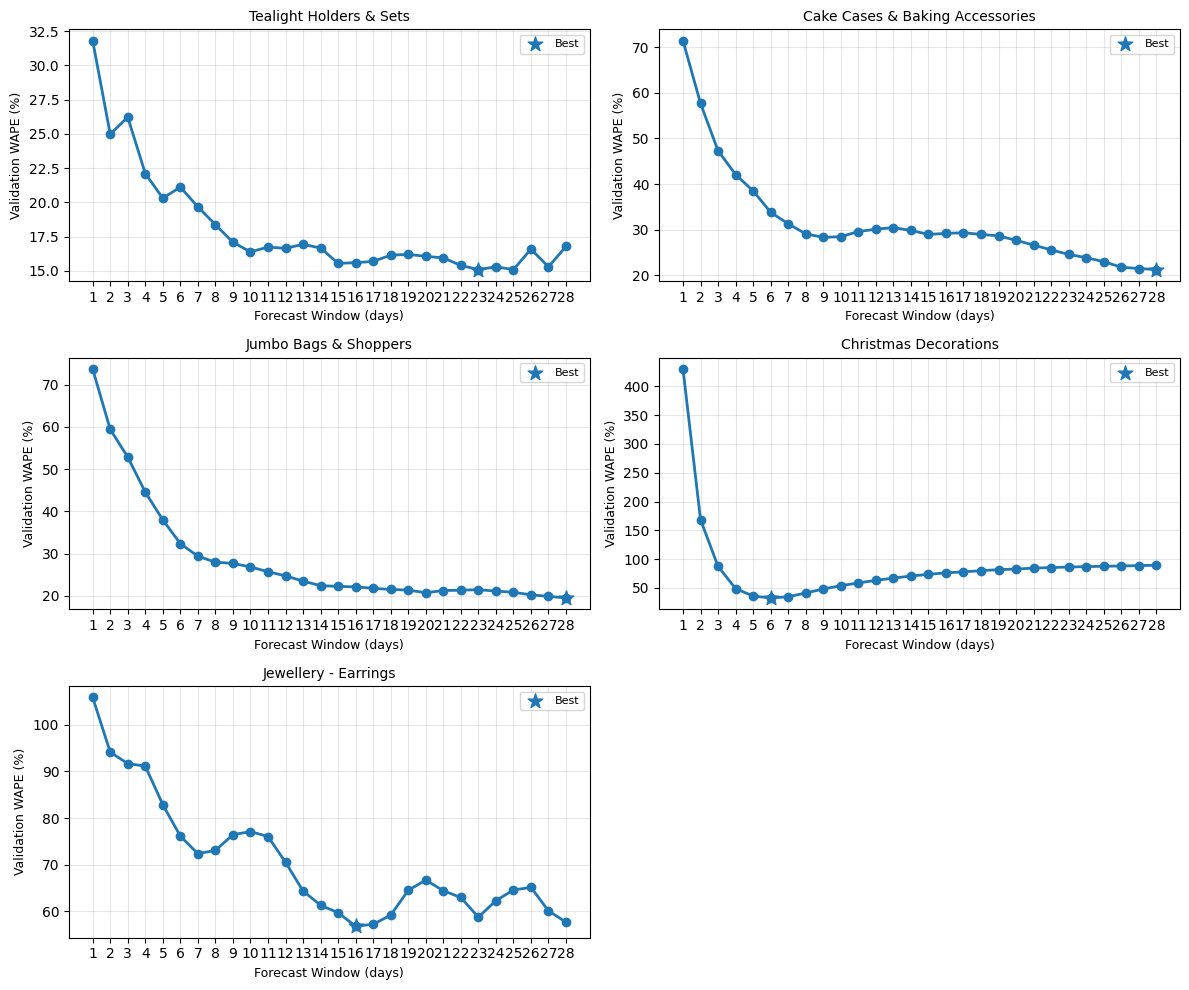

In [743]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i, category in enumerate(selected_categories):

    category_results = (
        window_results[window_results["Category"] == category]
        .sort_values("Forecast Window")
    )

    ax = axes[i]

    ax.plot(
        category_results["Forecast Window"],
        category_results["Validation WAPE (%)"],
        marker="o",
        linewidth=2
    )

    best = category_results.loc[
        category_results["Validation WAPE (%)"].idxmin()
    ]

    ax.scatter(
        best["Forecast Window"],
        best["Validation WAPE (%)"],
        marker="*",
        s=120,
        label="Best",
        zorder=5
    )

    ax.set_title(category, fontsize=10)
    ax.set_xlabel("Forecast Window (days)", fontsize=9)
    ax.set_ylabel("Validation WAPE (%)", fontsize=9)
    ax.set_xticks(forecast_windows)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

# Remove the empty subplot (since there are 5 categories)
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

### Interpretation

To determine the most appropriate forecasting horizon, the forecast window was systematically evaluated over the interval **1 to 28 days**, while keeping the lead time fixed at **7 days**. For each category, the best-performing forecasting model identified in the previous experiments was used.

The results show that the optimal forecast window differs considerably across product categories. While some categories achieve their best performance with relatively short forecasting horizons, others benefit from much longer horizons.

The optimal forecast windows obtained are:

- **Cake Cases & Baking Accessories:** **28 days**
- **Christmas Decorations:** **6 days**
- **Jewellery - Earrings:** **16 days**
- **Jumbo Bags & Shoppers:** **28 days**
- **Tealight Holders & Sets:** **23 days**

These findings demonstrate that there is no universally optimal forecasting horizon for all product categories. Instead, the optimal forecast window depends on the demand dynamics and variability of each category. Consequently, the selected forecast windows will be retained during the subsequent lead-time optimization step.

### Lead time Optimization

In [746]:
# Best forecast window found previously
best_forecast_windows = {
    "Cake Cases & Baking Accessories": 28,
    "Christmas Decorations": 6,
    "Jewellery - Earrings": 16,
    "Jumbo Bags & Shoppers": 28,
    "Tealight Holders & Sets": 23
}

lead_times = range(1, 15)

In [752]:
datasets_by_lead = {}
for Y in lead_times:
    datasets_by_lead[Y] = {}
    for category in selected_categories:
        X = best_forecast_windows[category]
        datasets_by_lead[Y][category] = prepare_single_category_dataset(
            daily_data=daily,
            category_name=category,
            X=X,
            Y=Y,
            holiday_dates=holiday_dates
        )

In [754]:
# Create train / validation / test splits for every lead time

splits_by_lead = {}
for Y in lead_times:
    splits_by_lead[Y] = {}
    for category, data in datasets_by_lead[Y].items():
        train_df, val_df, test_df = time_train_val_test_split(data)
        splits_by_lead[Y][category] = {
            "train": train_df,
            "validation": val_df,
            "test": test_df
        }

In [758]:
lead_results = []

for Y in lead_times:

    for category in selected_categories:

        splits = splits_by_lead[Y][category]

        train_df = splits["train"]
        val_df = splits["validation"]
        
        X = best_forecast_windows[category]
        target_col = f"target_X{X}_Y{Y}"
        
        X_train = train_df[features]
        y_train = train_df[target_col]

        X_val = val_df[features]
        y_val = val_df[target_col]

        # Best model selected previously
        if category == "Cake Cases & Baking Accessories":
            model = LinearRegression()
            model_name = "Linear Regression"

        elif category == "Christmas Decorations":
            model = None
            model_name = "Moving Average 7 days"

        elif category == "Jewellery - Earrings":
            model = RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
            model_name = "Random Forest"

        elif category == "Jumbo Bags & Shoppers":
            model = LinearRegression()
            model_name = "Linear Regression"

        elif category == "Tealight Holders & Sets":
            model = RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
            model_name = "Random Forest (Tuned)"

        if model is None:
            val_pred = val_df["rolling_sum_7"].values

        else:
            model.fit(X_train, y_train)
            val_pred = model.predict(X_val)

        val_mae, val_rmse, val_wape, val_r2, val_bias = evaluate_forecast(
            y_val,
            val_pred
        )

        lead_results.append({
            "Category": category,
            "Lead Time": Y,
            "Model": model_name,
            "Validation WAPE (%)": val_wape,
            "Validation R2": val_r2,
            "Validation Bias": val_bias
        })

lead_results = (
    pd.DataFrame(lead_results)
    .sort_values(["Category", "Validation WAPE (%)"])
    .reset_index(drop=True)
)

lead_results.round(3)

,Category,Lead Time,Model,Validation WAPE (%),Validation R2,Validation Bias
0,Cake Cases & Baking Accessories,14,Linear Regression,10.807,-0.376,-2625.135
1,Cake Cases & Baking Accessories,12,Linear Regression,12.383,-0.854,-3032.626
2,Cake Cases & Baking Accessories,13,Linear Regression,12.694,-0.842,-3110.579
3,Cake Cases & Baking Accessories,11,Linear Regression,12.893,-0.946,-3080.372
4,Cake Cases & Baking Accessories,10,Linear Regression,13.972,-1.188,-3249.348
...,...,...,...,...,...,...
65,Tealight Holders & Sets,11,Random Forest (Tuned),18.294,-2.973,721.810
66,Tealight Holders & Sets,10,Random Forest (Tuned),18.830,-3.199,892.432
67,Tealight Holders & Sets,12,Random Forest (Tuned),19.268,-3.289,915.011
68,Tealight Holders & Sets,13,Random Forest (Tuned),20.334,-3.915,1072.933


In [760]:
best_lead_times = (
    lead_results
    .sort_values(["Category", "Validation WAPE (%)"])
    .groupby("Category")
    .first()
    .reset_index()
)

best_lead_times.round(3)

,Category,Lead Time,Model,Validation WAPE (%),Validation R2,Validation Bias
0,Cake Cases & Baking Accessories,14,Linear Regression,10.807,-0.376,-2625.135
1,Christmas Decorations,1,Moving Average 7 days,31.301,0.681,-551.647
2,Jewellery - Earrings,9,Random Forest,48.769,0.039,10.606
3,Jumbo Bags & Shoppers,14,Linear Regression,19.750,-4.983,-3920.792
4,Tealight Holders & Sets,1,Random Forest (Tuned),8.264,-0.114,-432.459


In [762]:
current_lead = (
    lead_results[lead_results["Lead Time"] == 7]
    [["Category", "Validation WAPE (%)"]]
    .rename(columns={
        "Validation WAPE (%)": "Validation WAPE at 7 days (%)"
    })
)

lead_time_comparison = best_lead_times.merge(
    current_lead,
    on="Category"
)

lead_time_comparison["WAPE Improvement (%)"] = (
    lead_time_comparison["Validation WAPE at 7 days (%)"]
    - lead_time_comparison["Validation WAPE (%)"]
)

lead_time_comparison = lead_time_comparison[
    [
        "Category",
        "Lead Time",
        "Model",
        "Validation WAPE (%)",
        "Validation WAPE at 7 days (%)",
        "Validation R2",
        "Validation Bias",
        "WAPE Improvement (%)"
    ]
]

lead_time_comparison.round(3)

,Category,Lead Time,Model,Validation WAPE (%),Validation WAPE at 7 days (%),Validation R2,Validation Bias,WAPE Improvement (%)
0,Cake Cases & Baking Accessories,14,Linear Regression,10.807,17.159,-0.376,-2625.135,6.352
1,Christmas Decorations,1,Moving Average 7 days,31.301,35.766,0.681,-551.647,4.465
2,Jewellery - Earrings,9,Random Forest,48.769,49.245,0.039,10.606,0.476
3,Jumbo Bags & Shoppers,14,Linear Regression,19.750,22.905,-4.983,-3920.792,3.155
4,Tealight Holders & Sets,1,Random Forest (Tuned),8.264,14.024,-0.114,-432.459,5.760


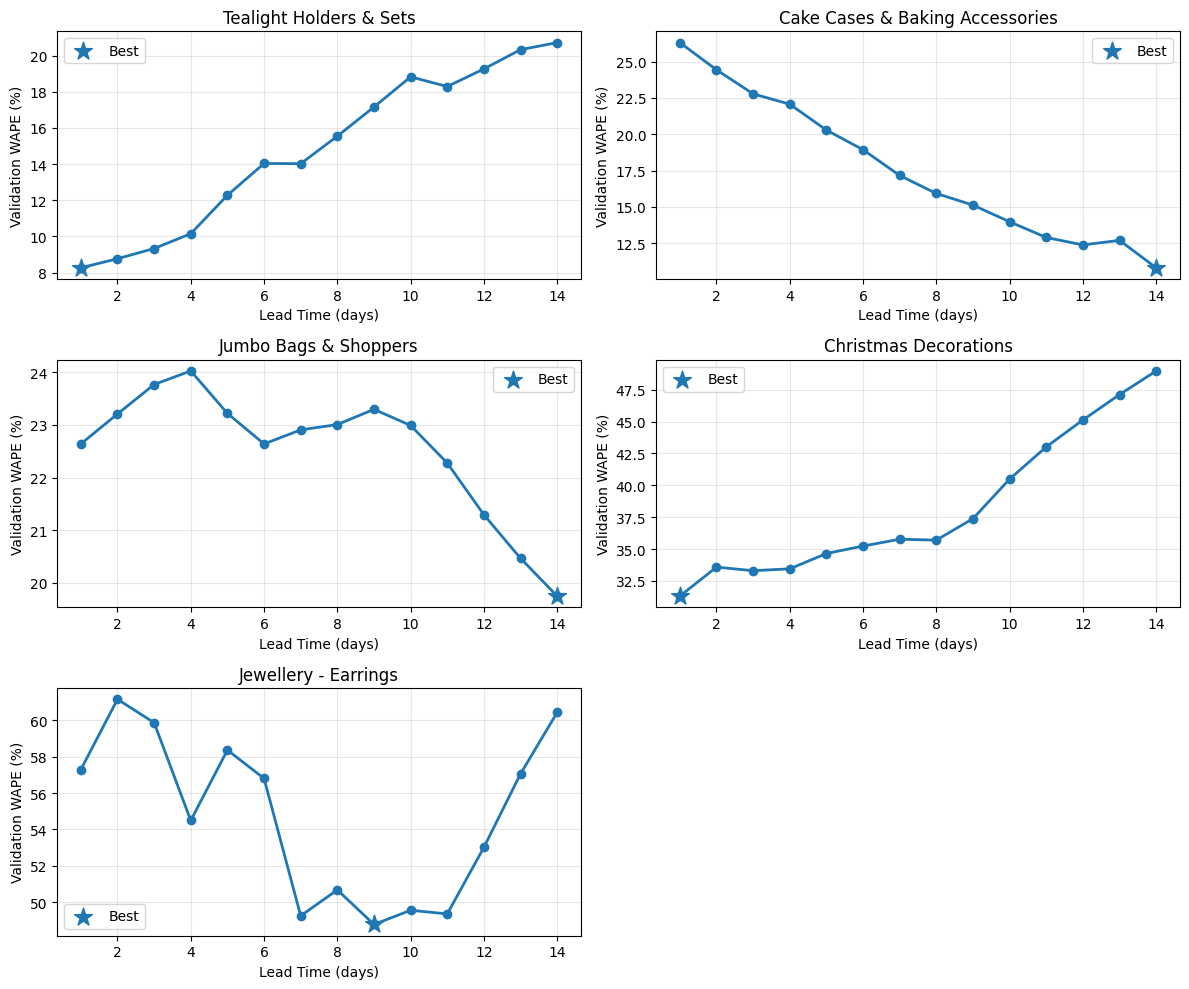

In [764]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i, category in enumerate(selected_categories):

    df = lead_results[
        lead_results["Category"] == category
    ].sort_values("Lead Time")

    ax = axes[i]

    ax.plot(
        df["Lead Time"],
        df["Validation WAPE (%)"],
        marker="o",
        linewidth=2
    )

    best = df.loc[df["Validation WAPE (%)"].idxmin()]

    ax.scatter(
        best["Lead Time"],
        best["Validation WAPE (%)"],
        marker="*",
        s=180,
        label="Best"
    )

    ax.set_title(category)
    ax.set_xlabel("Lead Time (days)")
    ax.set_ylabel("Validation WAPE (%)")
    ax.grid(alpha=0.3)
    ax.legend()

fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

### Interpretation

To identify the optimal lead time, the forecasting models were evaluated using lead times ranging from **1 to 14 days**, while keeping the forecast window fixed at its previously optimized value for each product category.

The results show that the optimal lead time varies across categories, confirming that the delay between the prediction date and the beginning of the forecasting horizon should be adapted to the characteristics of each product category.

The optimal lead times obtained are:

- **Cake Cases & Baking Accessories:** **14 days**
- **Christmas Decorations:** **1 day**
- **Jewellery - Earrings:** **9 days**
- **Jumbo Bags & Shoppers:** **14 days**
- **Tealight Holders & Sets:** **1 day**

Compared with the initial lead time of **7 days**, every category achieved a lower Validation WAPE after optimization. The largest improvements were obtained for **Cake Cases & Baking Accessories** (6.35 percentage points) and **Tealight Holders & Sets** (5.76 percentage points), while **Jewellery - Earrings** showed only a marginal improvement (0.48 percentage points).

These results indicate that selecting an appropriate lead time is an important component of the forecasting framework, as it consistently improves predictive accuracy across all product categories. Therefore, the optimized lead times will be retained for the final forecasting models.